### ENTREGA 3.1. Preprocesado y preparación de series temporales

Tareas a realizar: 

- Preparar los indicadores generados en la Entrega 2 para análisis temporal:
    - Limpiar fechas
    - Ordenar cronológicamente
    - Elegir la granularidad (mensual, trimestral, anual...)
    - Generar series agregadas
- Realizar primeras visualizaciones para ver si los datos parecen confirmar o desmentir nuestra hipótesis.


In [6]:
# Importación de librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# Cargamos el conjunto de datos procesado de la Entrega2
data = pd.read_csv('../data/processed/dataset_boe_universidades_processed.csv', index_col="Unnamed: 0")
data.head()

,ID_Disposicion,Fecha_Publicacion,Año_Semana,Año,Bloque_3dias,Mes,Bloques_dias_semana,Dia_semana_num,longitud_titulo,quinquenio,...,Castellón,Badajoz,A Coruña,Pontevedra,Madrid,Murcia,Navarra,Bizkaia,Gipuzkoa,La Rioja
0,BOE-A-1995-26,1995-01-02,1995-01,1995,0,1,0,0,30,1995,...,0,0,0,0,1,0,0,0,0,0
1,BOE-A-1995-27,1995-01-02,1995-01,1995,0,1,0,0,42,1995,...,0,0,0,0,1,0,0,0,0,0
2,BOE-A-1995-77,1995-01-03,1995-01,1995,0,1,0,1,48,1995,...,0,0,0,0,1,0,0,0,0,0
3,BOE-A-1995-78,1995-01-03,1995-01,1995,0,1,0,1,40,1995,...,0,0,0,0,0,0,0,0,0,0
4,BOE-A-1995-205,1995-01-03,1995-01,1995,0,1,0,1,45,1995,...,0,0,1,0,0,0,0,0,0,0


Aseguramos tipos de datos y orden cronológico de los datos.

In [8]:
# Comprobamos tipo de dato de la columna fecha
data['Fecha_Publicacion'].dtypes

dtype('O')

In [9]:
# Convertimos la columna 'Fecha_Publicacion' a formato datetime
data['Fecha_Publicacion'] = pd.to_datetime(data['Fecha_Publicacion'], errors='coerce')

# Verificamos la conversión
data['Fecha_Publicacion'].dtype

dtype('<M8[ns]')

In [10]:
# Comprobamos si esta ordenado cronologicamente 

def is_chronologically_sorted(df: pd.DataFrame, date_column: str) -> bool:
    """
    Comprueba si un DataFrame está ordenado cronológicamente 
    (de menor a mayor fecha) según la columna indicada.

    Devuelve True si está ordenado, False si no.
    """
    # Asegurar formatos datetime
    dates = pd.to_datetime(df[date_column], errors='coerce')
    
    # Comprobar si está ordenado ascendentemente
    return dates.is_monotonic_increasing

is_chronologically_sorted(data, 'Fecha_Publicacion')

True

---

Se codifican varias agrupaciones con distinta granularidad de cara a poder probar los modelos posteriormente y ver qué granularidad funciona mejor. Presentamos indicadores de: 

1. **Por recuento**: suma de titulares para esa fecha
2. **Por categoría principal**: recuento de nº de titulares para esa categoría por fecha. Se dice que un titular es de x categoría si tiene el mayor valor la columna de la categoría comparado con el resto.
3. **Por recuento de universidad**: numero de apariciones de universidad pública y privada para cada granularidad. 
4. **Por recuento de comunidades**: suma de las veces que aparece cada comunidad para cada granularidad. 

Con la combinación de todos los indicadores se crean tablas para cada granularidad que posteriormente se exportan a csvs para poder trabajar mejor con ellos y los modelos de series temporales posteriores del proyecto. 

In [11]:
# Función auxiliar para el indicador por categorías que identifica la categoría principal como aqeuella con mayor valor en la fila

def add_main_category(df, category_cols):
    """
    Añade una columna 'main_category' a un dataframe.
    La categoría se elige como aquella columna cuyo valor es mayor en la fila.
    
    category_cols: lista de columnas con valores numéricos
    """
    # Verificar que las columnas existen
    for col in category_cols:
        if col not in df.columns:
            raise ValueError(f"La columna {col} no existe en el DataFrame")

    # Seleccionar la categoría con mayor valor en cada fila
    df['main_category'] = df[category_cols].idxmax(axis=1)
    return df


In [12]:
def generate_indicators_complete(
        df,
        date_col="Fecha_Publicacion",
        category_cols=None,
        university_cols=None, 
        community_cols=None
    ):
    """
    Genera indicadores temporales en múltiples granularidades.

    Parámetros:
    - category_cols: lista de columnas numéricas → se usa para determinar main_category
    - university_cols: lista de columnas binarias → indicador público/privado
    - community_cols: lista de columnas binarias → indicador comunidades

    return: diccionario con granularidades (daily, 3days, weekly, monthly, quarterly, annual)
    """

    df = df.copy()

    # Limpieza de fecha
    df = df.dropna(subset=[date_col])
    df = df.sort_values(date_col)
    df = df.set_index(date_col)

    # Indicador base
    df['count'] = 1


    # 1) main_category
    if category_cols:
        for col in category_cols:
            if col not in df.columns:
                raise ValueError(f"Columna no encontrada: {col}")
        
        df["main_category"] = df[category_cols].idxmax(axis=1)


    # Configurar granularidades
    granularities = {
        "daily": "D",
        "3days": "3D",
        "weekly": "W",
        "monthly": "M",
        "quarterly": "Q",
        "annual": "A"
    }

    results = {}


    # Bucle por granularidad
    for name, freq in granularities.items():

        parts = []  # almacenará cada bloque de indicadores

        # 1) total_count
        total_count = df["count"].resample(freq).sum().rename("total_count")
        parts.append(total_count)

        # 2) count_by_type 
        if category_cols:
            type_count = (
                df.groupby([pd.Grouper(freq=freq), 'main_category'])
                  .size()
                  .unstack(fill_value=0)
            )
            parts.append(type_count)

        # 3) universidad (publica/privada) — generalizado
        if university_cols:
            for col in university_cols:
                if col not in df.columns:
                    raise ValueError(f"Columna no encontrada: {col}")
            
            uni_counts = df[university_cols].resample(freq).sum()
            # renombrar columnas
            # uni_counts = uni_counts.rename(columns=lambda c: f"{c}_count")
            parts.append(uni_counts)

        # 4) comunidad (otros indicadores) — generalizado
        if community_cols:
            for col in community_cols:
                if col not in df.columns:
                    raise ValueError(f"Columna no encontrada: {col}")
            
            community_counts = df[community_cols].resample(freq).sum()
            # community_counts = community_counts.rename(columns=lambda c: f"{c}_count")
            parts.append(community_counts)

        # Combinar todo
        combined = pd.concat(parts, axis=1)

        results[name] = combined

    return results

In [13]:
# Uso

data_copy = data.copy()
category_cols = ['empleo', 'economía', 'tecnología','salud']
university_cols = ["publica", "privada"]
community_cols = ['Sevilla', 'Granada', 'Córdoba', 'Málaga', 'Cádiz', 'Almería', 'Huelva', 'Jaén', 'Zaragoza', 'Asturias','Islas Baleares', 'Santa Cruz de Tenerife', 'Las Palmas', 
                  'Cantabria','Salamanca', 'Valladolid', 'León', 'Burgos', 'Ávila', 'Ciudad Real','Barcelona', 'Girona', 'Lleida', 'Tarragona', 'Valencia', 'Alicante', 'Castellón', 
                  'Badajoz', 'A Coruña', 'Pontevedra', 'Madrid', 'Murcia', 'Navarra', 'Bizkaia', 'Gipuzkoa', 'La Rioja']

indicators = generate_indicators_complete(
    data_copy,
    date_col="Fecha_Publicacion",
    category_cols=category_cols,
    university_cols=university_cols,
    community_cols=community_cols
)

C:\Users\Paula\AppData\Local\Temp\ipykernel_18536\3913865644.py:58: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  total_count = df["count"].resample(freq).sum().rename("total_count")
C:\Users\Paula\AppData\Local\Temp\ipykernel_18536\3913865644.py:64: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby([pd.Grouper(freq=freq), 'main_category'])
C:\Users\Paula\AppData\Local\Temp\ipykernel_18536\3913865644.py:76: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  uni_counts = df[university_cols].resample(freq).sum()
C:\Users\Paula\AppData\Local\Temp\ipykernel_18536\3913865644.py:87: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  community_counts = df[community_cols].resample(freq).sum()
C:\Users\Paula\AppData\Local\Temp\ipykernel_18536\3913865644.py:58: FutureWarning: 'Q' is

In [14]:
## Sacamos tamaños de cada agrupacion resultante
dayly = indicators["daily"]
three_days = indicators["3days"] 
weekly = indicators["weekly"]
monthly = indicators["monthly"]
quarterly = indicators["quarterly"]
annual = indicators["annual"]

print("Dayly shape:", dayly.shape)
print("3 Days shape:", three_days.shape)
print("Weekly shape:", weekly.shape)
print("Monthly shape:", monthly.shape)
print("Quarterly shape:", quarterly.shape)
print("Annual shape:", annual.shape)

Dayly shape: (10621, 43)
3 Days shape: (3541, 43)
Weekly shape: (1518, 43)
Monthly shape: (349, 43)
Quarterly shape: (117, 43)
Annual shape: (30, 43)


In [15]:
# # Guardamos un csv para cada granularidad -- en caso de quererlo
# dayly.to_csv("indicators_general_dayly.csv")    
# three_days.to_csv("indicators_general_3days.csv")
# weekly.to_csv("indicators_general_weekly.csv")  
# monthly.to_csv("indicators_general_monthly.csv")
# quarterly.to_csv("indicators_general_quarterly.csv")
# annual.to_csv("indicators_general_annual.csv")

---

### Más análisis más específicos 

Con este preprocesado de los datos se busca orientar el análisis hacia nuestra hipótesis para poder confirmarla o desmentirla; si la recordamos: 

*"Entre 1995 y 2024, la proporción de titulares del BOE relacionados con tecnología en universidades públicas de la Comunidad de Madrid aumenta moderadamente (≈ +1.1% anual), mientras que los relativos a empleo muestran una tendencia variable con disminución general (≈ -2.3% anual), lo que sugiere un cambio gradual de foco institucional desde temas laborales hacia la innovación tecnológica."*

Una vez hemos hecho agrupaciones "en general" y en vista de los tamaños resultantes, decidimos quedarnos con la **agrupación diaria, cada 3 días y semanal** (de cara a tener datos suficientes para el análisis de series temporales), además de la **agrupación anual** (para poder tener una visión más de conjunto); y separar por comunidades de cara a tener un análisis más sencillo e ilustrativo. 

En primer lugar, vamos a identificar las comunidades que más aparece en el dataset completo. 

In [16]:
comm_apariciones = data[community_cols].sum().sort_values(ascending=False)
top_5_communities = comm_apariciones.head(5).index.tolist()
top_5_communities

['Madrid', 'Valencia', 'Barcelona', 'Sevilla', 'Granada']

Filtramos entoces para cada comunidad para el top5 de comunidades que más aparecen en los datos.

In [17]:
data_madrid = data[data['Madrid'] == 1]
data_valencia = data[data['Valencia'] == 1]
data_barcelona = data[data['Barcelona'] == 1]
data_sevilla = data[data['Sevilla'] == 1]
data_granada = data[data['Granada'] == 1]


print(f'Dataset Madrid: {data_madrid.shape}')
print(f'Dataset Valencia: {data_valencia.shape}')
print(f'Dataset Barcelona: {data_barcelona.shape}')
print(f'Dataset Sevilla: {data_sevilla.shape}')
print(f'Dataset Granada: {data_granada.shape}')

Dataset Madrid: (39573, 52)
Dataset Valencia: (11876, 52)
Dataset Barcelona: (9554, 52)
Dataset Sevilla: (7644, 52)
Dataset Granada: (7571, 52)


En vista de estos tamaños se confirma que la Comunidad de Madrid es la que más apariencia tiene en el conjunto, por lo que tiene sentido basar la hipótesis en ella. Se reducen los análisis entonces a partir de ahora sólo a Madrid. 

Modificamos el codigo de generación de indicadores eliminando el análisis por comunidades dado que los datos se van a segmentar por una en específico. Eliminamos también algunas agrupaciones y añadimos otro indicador que calcule la suma de todos los valores de una categoría para una fecha o agrupación de fechas específica. 

In [18]:
def generate_indicators_community(
        df,
        date_col="Fecha_Publicacion",
        category_cols=None,
        university_cols=None
    ):
    """
    Genera indicadores temporales en múltiples granularidades.

    Parámetros:
    - category_cols: lista de columnas numéricas → se usa para determinar main_category
    - university_cols: lista de columnas binarias → indicador público/privado

    return: diccionario con granularidades (daily, 3days, weekly)
    """

    df = df.copy()

    # Limpieza de fecha
    df = df.dropna(subset=[date_col])
    df = df.sort_values(date_col)
    df = df.set_index(date_col)

    # Indicador base
    df['count'] = 1


    # 1) main_category
    if category_cols:
        for col in category_cols:
            if col not in df.columns:
                raise ValueError(f"Columna no encontrada: {col}")
        
        df["main_category"] = df[category_cols].idxmax(axis=1)


    # Configurar granularidades
    granularities = {
        "daily": "D",
        "3days": "3D",
        "weekly": "W", 
        "annual": "A"
    }

    results = {}


    # Bucle por granularidad
    for name, freq in granularities.items():

        parts = []  # almacenará cada bloque de indicadores

        # 1) total_count
        total_count = df["count"].resample(freq).sum().rename("total_count")
        parts.append(total_count)

        # 2) count_by_type 
        if category_cols:
            type_count = (
                df.groupby([pd.Grouper(freq=freq), 'main_category'])
                  .size()
                  .unstack(fill_value=0)
            )
            # renombrar columnas
            type_count = type_count.rename(columns=lambda c: f"{c}_count")
            parts.append(type_count)

        # 3) sum_by_type 
        if category_cols:
            sum_by_type = df.groupby([pd.Grouper(freq=freq)])[category_cols].sum()
            # renombrar columnas
            sum_by_type = sum_by_type.rename(columns=lambda c: f"{c}_sum")
            parts.append(sum_by_type)

        # 4) universidad (publica/privada) — generalizado
        if university_cols:
            for col in university_cols:
                if col not in df.columns:
                    raise ValueError(f"Columna no encontrada: {col}")
            
            uni_counts = df[university_cols].resample(freq).sum()
            parts.append(uni_counts)


        # Combinar todo
        combined = pd.concat(parts, axis=1)

        results[name] = combined

    return results

In [19]:
category_cols = ['empleo', 'economía', 'tecnología','salud']
university_cols = ["publica", "privada"]


indicators_madrid = generate_indicators_community(
    data_madrid,
    date_col="Fecha_Publicacion",
    category_cols=category_cols,
    university_cols=university_cols
)

C:\Users\Paula\AppData\Local\Temp\ipykernel_18536\4017552726.py:54: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  total_count = df["count"].resample(freq).sum().rename("total_count")
C:\Users\Paula\AppData\Local\Temp\ipykernel_18536\4017552726.py:60: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.groupby([pd.Grouper(freq=freq), 'main_category'])
C:\Users\Paula\AppData\Local\Temp\ipykernel_18536\4017552726.py:70: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  sum_by_type = df.groupby([pd.Grouper(freq=freq)])[category_cols].sum()
C:\Users\Paula\AppData\Local\Temp\ipykernel_18536\4017552726.py:81: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  uni_counts = df[university_cols].resample(freq).sum()


In [20]:
# Sacamos tamaños de cada agrupacion resultante para cada comunidad 
dayly_madrid = indicators_madrid["daily"]
three_days_madrid = indicators_madrid["3days"] 
weekly_madrid = indicators_madrid["weekly"]
annual_madrid = indicators_madrid["annual"]

print("Dayly Madrid shape:", dayly_madrid.shape)
print("3 Days Madrid shape:", three_days_madrid.shape)
print("Weekly Madrid shape:", weekly_madrid.shape)
print("Annual Madrid shape:", annual_madrid.shape)

Dayly Madrid shape: (10621, 11)
3 Days Madrid shape: (3541, 11)
Weekly Madrid shape: (1518, 11)
Annual Madrid shape: (30, 11)


In [21]:
# Guardo todos los csvs por separado -- si se desea

# dayly_madrid.to_csv("indicators_madrid_dayly.csv")    
# three_days_madrid.to_csv("indicators_madrid_3days.csv")
# weekly_madrid.to_csv("indicators_madrid_weekly.csv")
# annual_madrid.to_csv("indicators_madrid_annual.csv")

---

#### **VISUALIZACIONES** 

Creamos en primer lugar una visualización que nos represente la evolución de los valores de cada columna con el paso del tiempo (de todas las columnas a la vez).

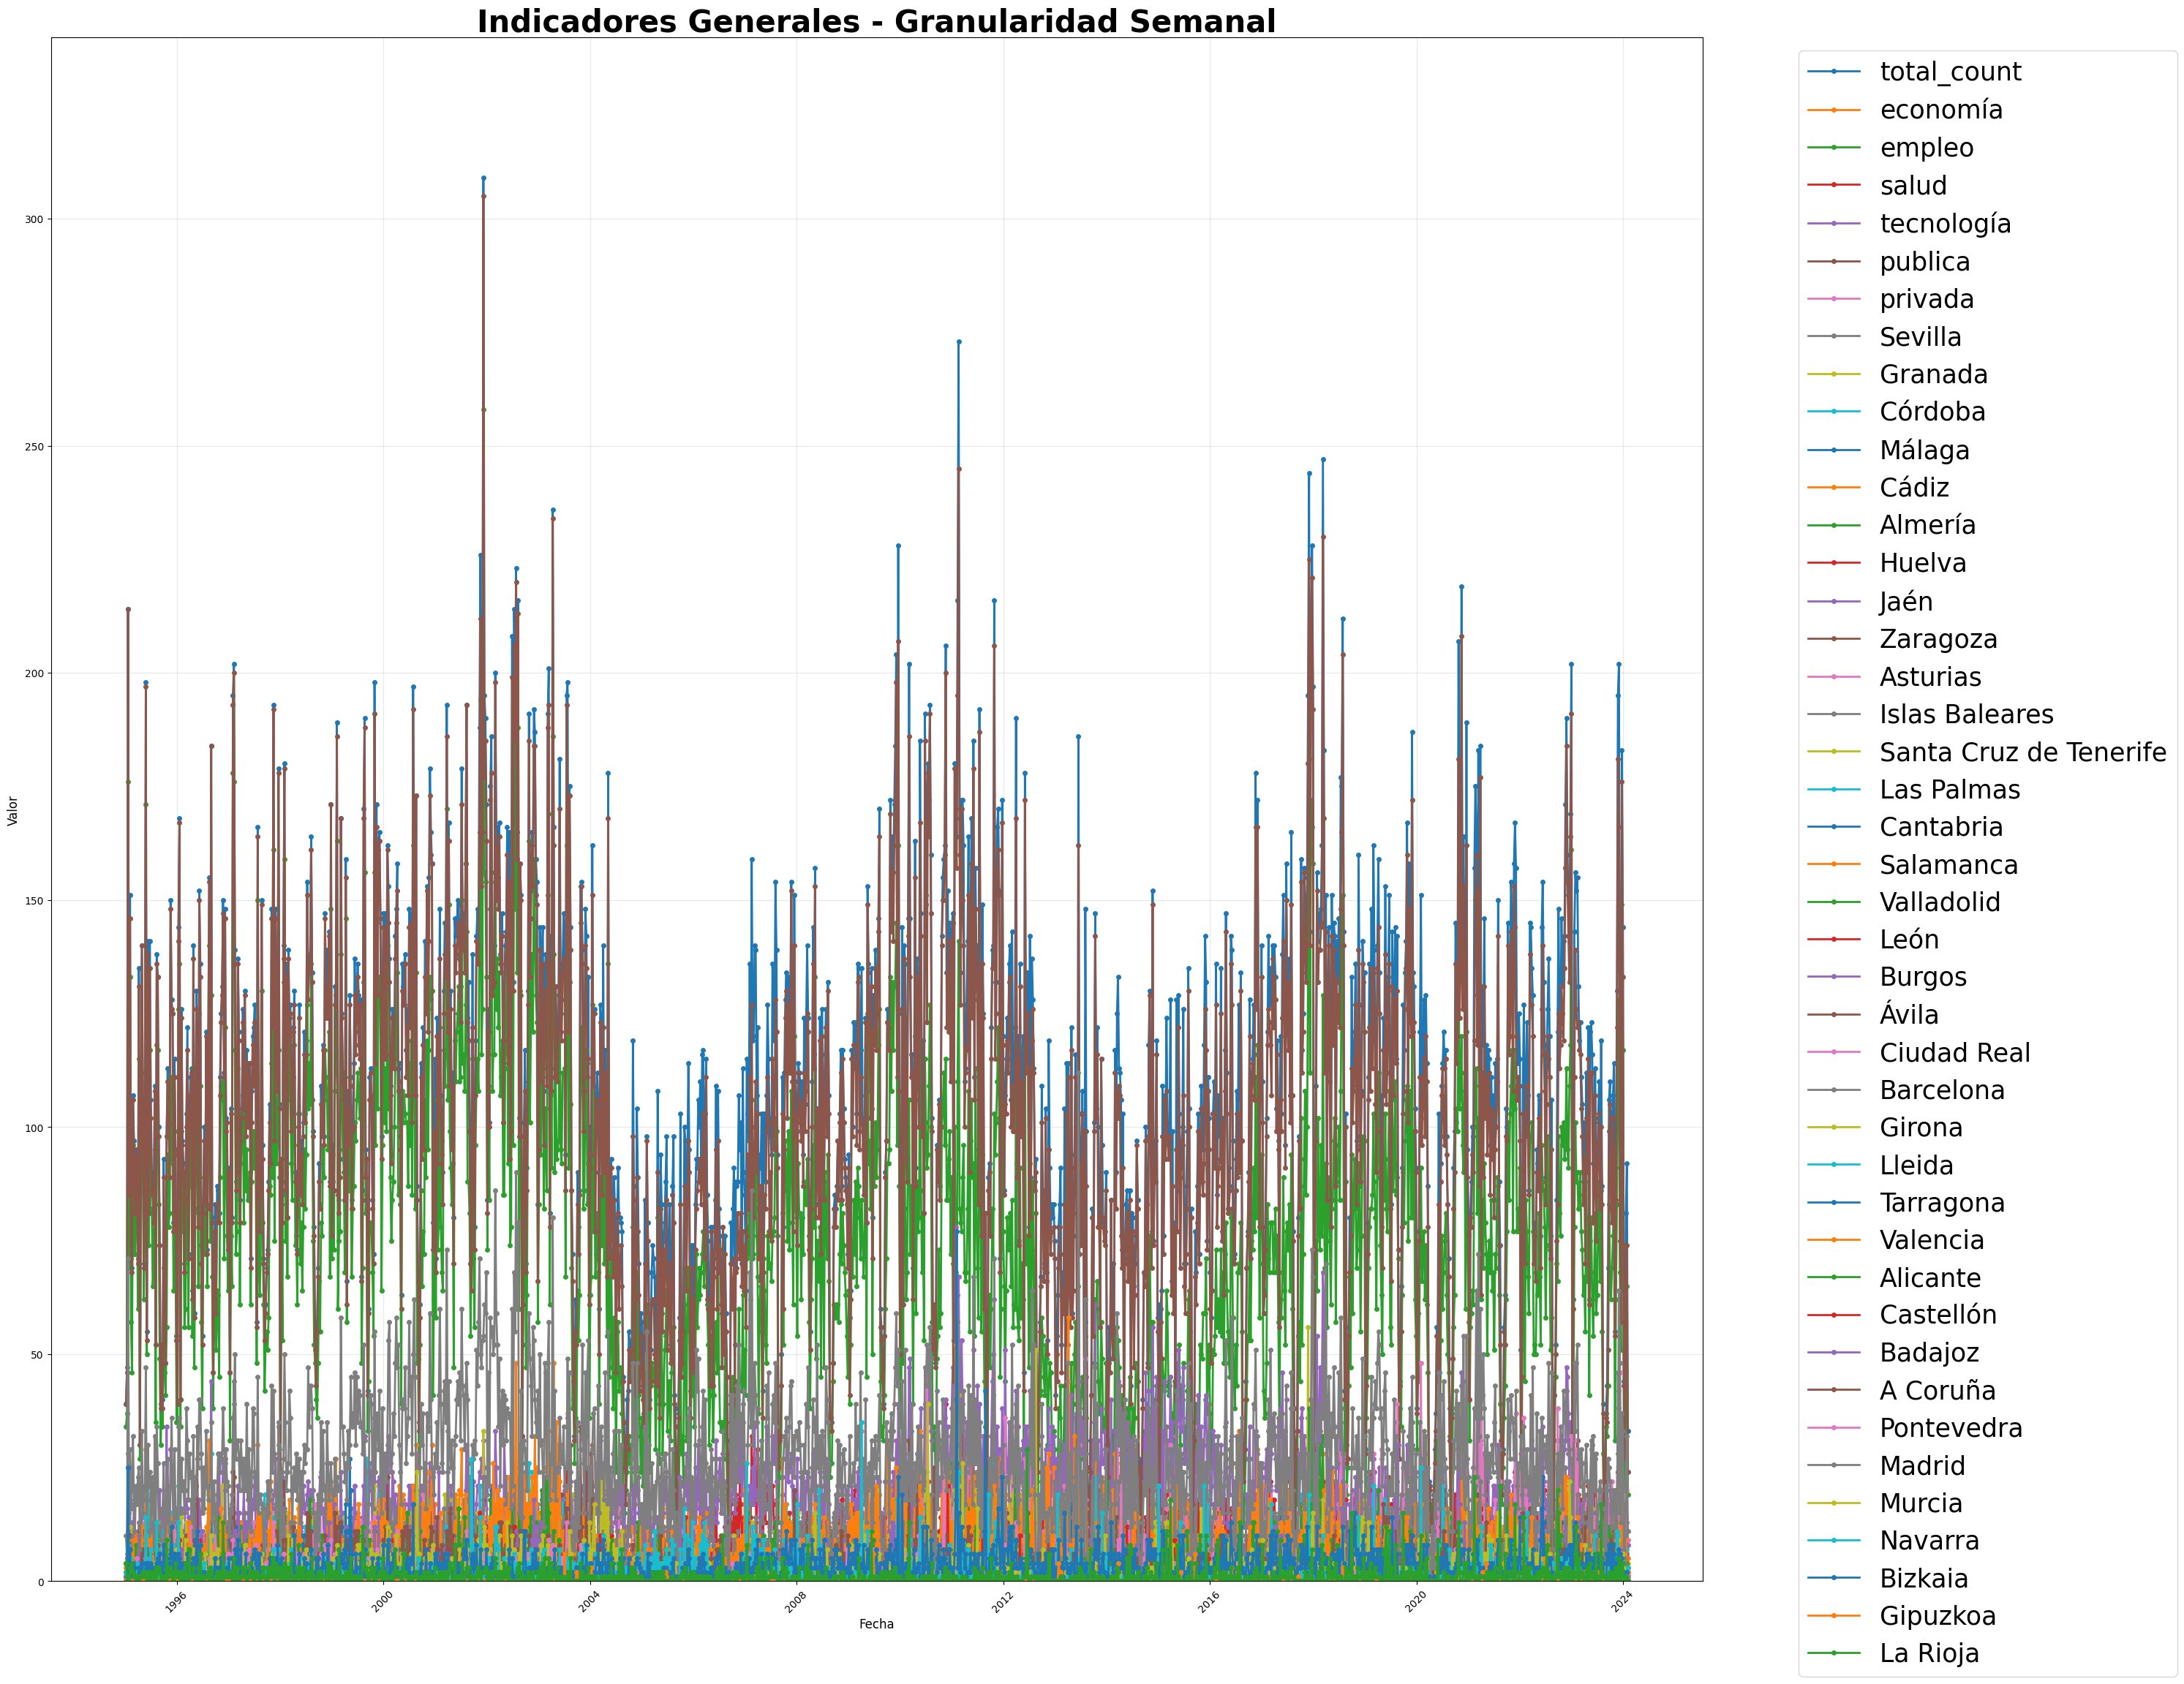

In [22]:
def plot_time_series(df, title="Time Series Visualization", figsize=(30, 25)):
    """
    Crea un gráfico de líneas con todas las columnas del DataFrame
    y ajusta dinámicamente el eje Y para mostrar todas las series.
    """
    plt.figure(figsize=figsize)

    for column in df.columns:
        plt.plot(df.index, df[column], marker='o', label=column, linewidth=2, markersize=4)

    # Ajustar eje Y automáticamente con margen
    plt.margins(y=0.2)

    # También puedes fijarlo manualmente (opcional):
    plt.ylim(df.min().min() * 0.9, df.max().max() * 1.1)

    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Valor', fontsize=12)
    plt.title(title, fontsize=30, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=25)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Usar la función con los datos

# Ejemplo: Visualizar datos generales (granularidad semanal)
plot_time_series(weekly, title="Indicadores Generales - Granularidad Semanal")

Vemos que resulta muy dificil sacar información útil a simple vista dada la cantidad de columnas (indicadores). Vamos a reducir nuestras columnas a los indicadores relacionados con nuestra hipótesis inicial. 

Por tanto nos quedamos con las columnas: 

- **total_count**: recuento de titulares para la fecha
- **tecnología**: recuento de apariciones de titulares con tecnología como categoría principal 
- **empleo**: recuento de apariciones de titulares con empleo como categoría principal
- **publica**: recuento de apariciones de titulares relacionados con universidades públicas
- **Madrid**: recuento de apariciones de titulares relacionados con la Comunidad de Madrid

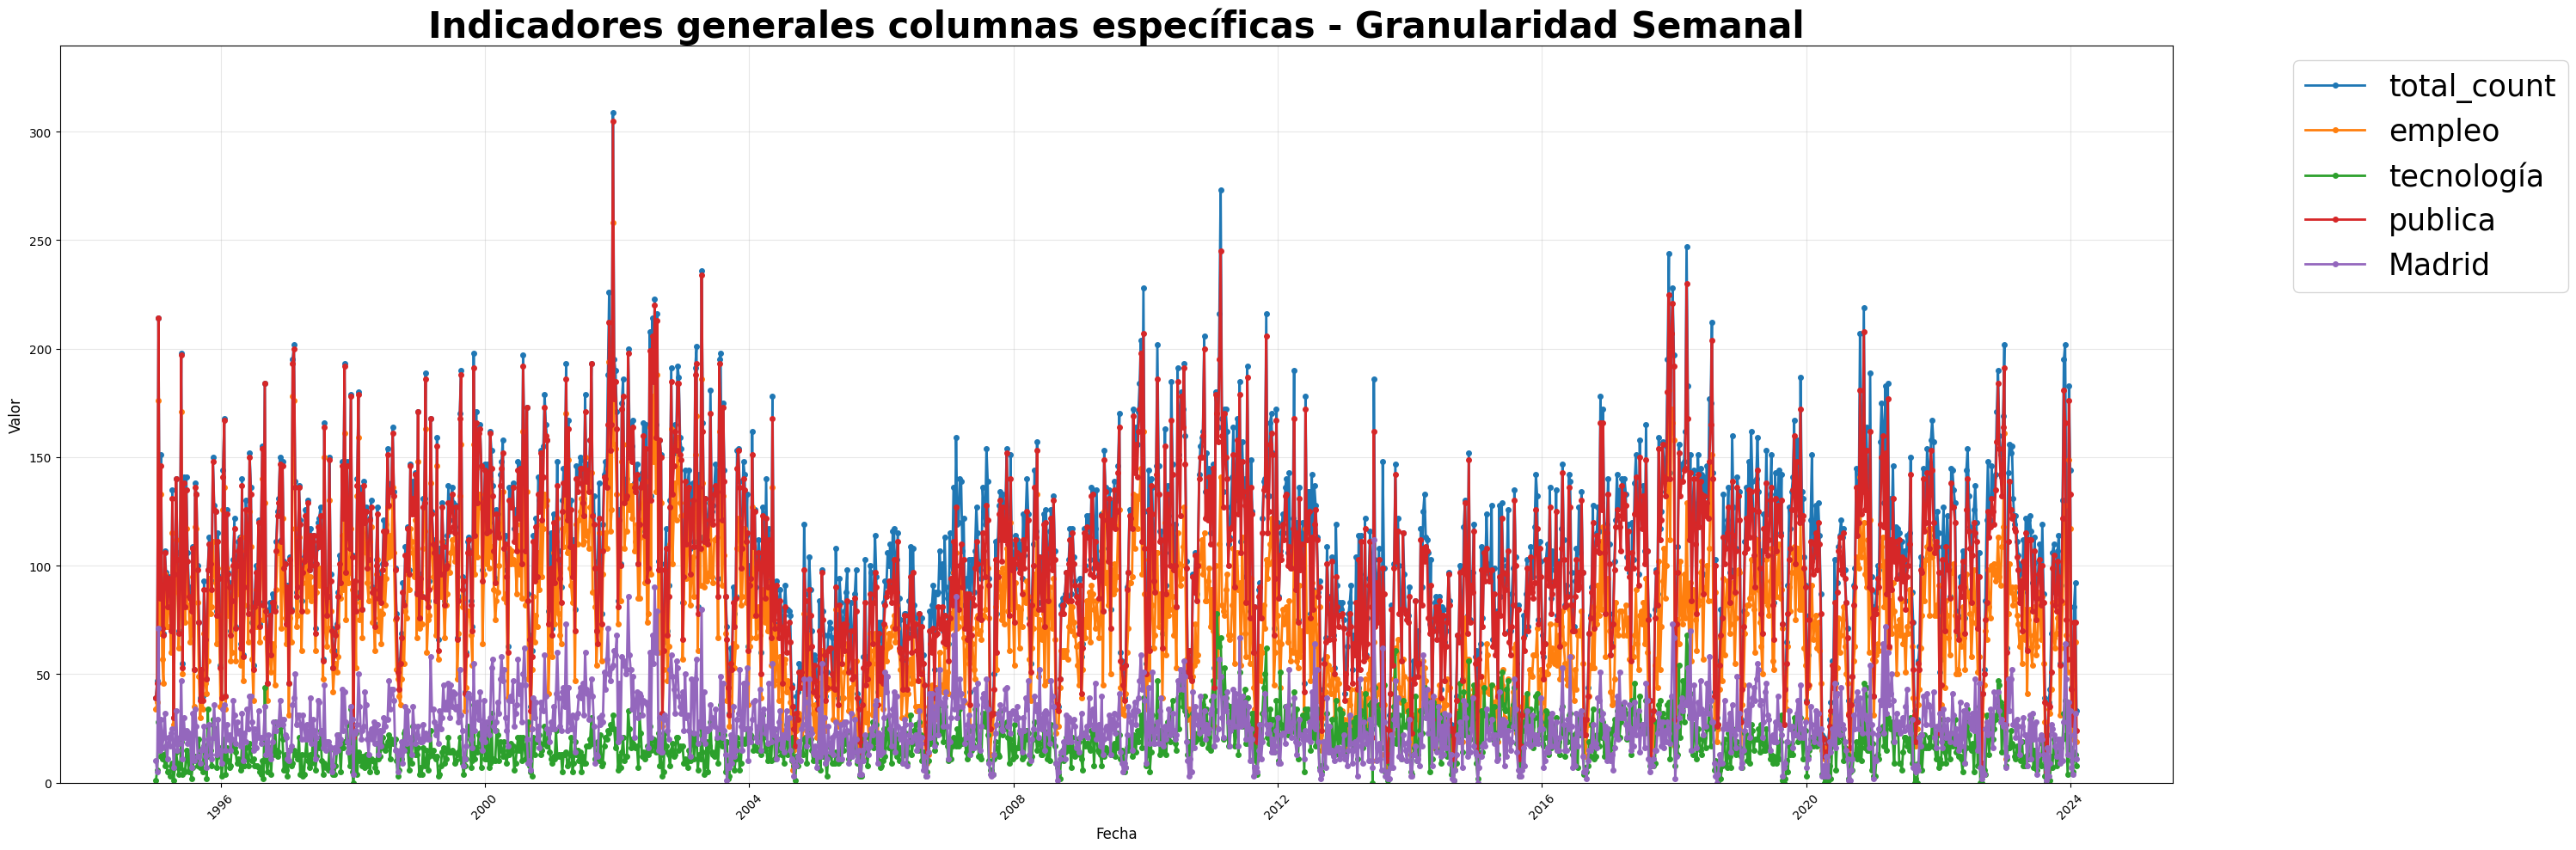

In [23]:
cols = ['total_count', 'empleo', 'tecnología', 'publica','Madrid']

# Aplicamos de nuevo nuestra función de visualización
plot_time_series(weekly[cols], title="Indicadores generales columnas específicas - Granularidad Semanal", figsize=(30, 10))

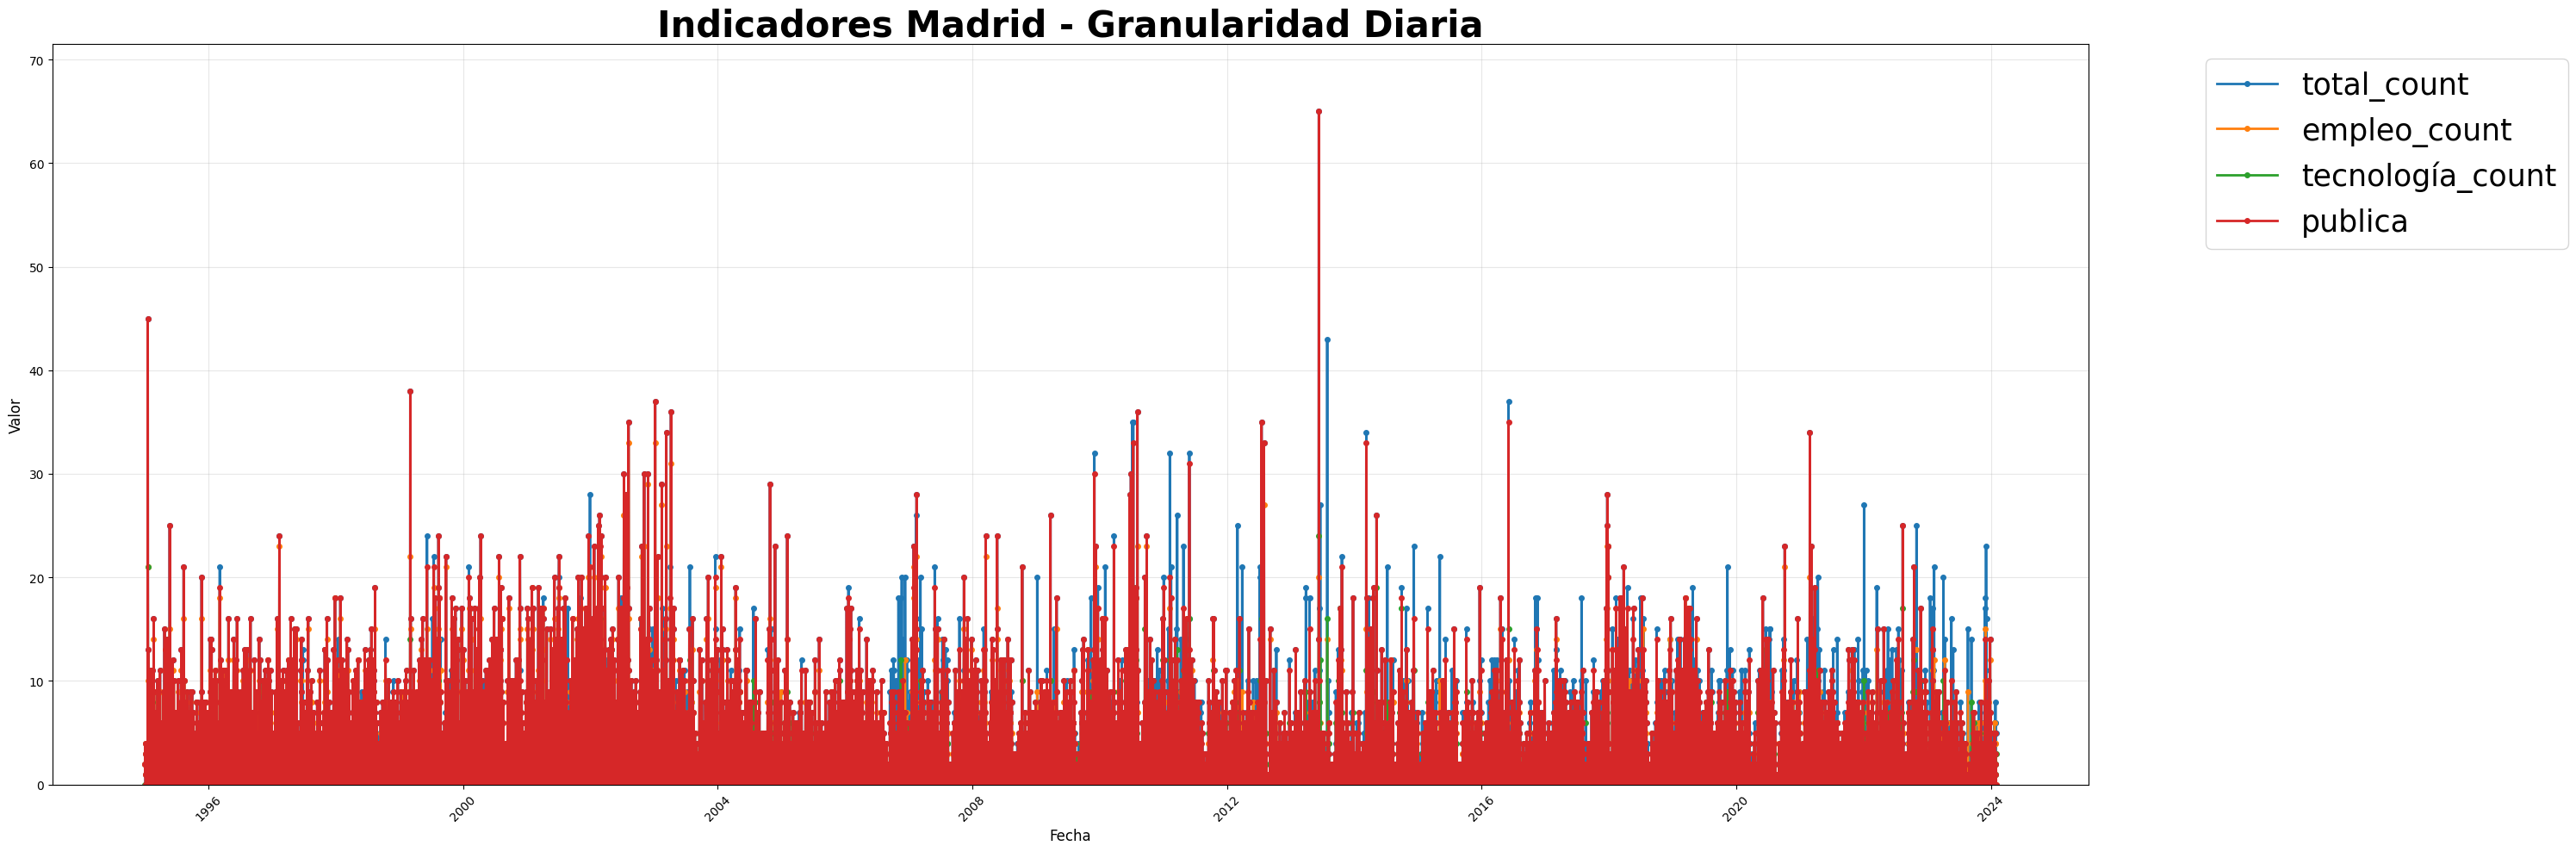

In [24]:
# Y si lo visualizamos en nuestro dataset de madrid particular 
cols_mad = ['total_count', 'empleo_count', 'tecnología_count', 'publica']
plot_time_series(dayly_madrid[cols_mad], title="Indicadores Madrid - Granularidad Diaria", figsize=(30, 10))

Pero, para no descuidar ningún tipo de información, ejecutamos también el gráfico icluyendo la información de universidades privadas (aunque nuestra hipótesis no las menciona).

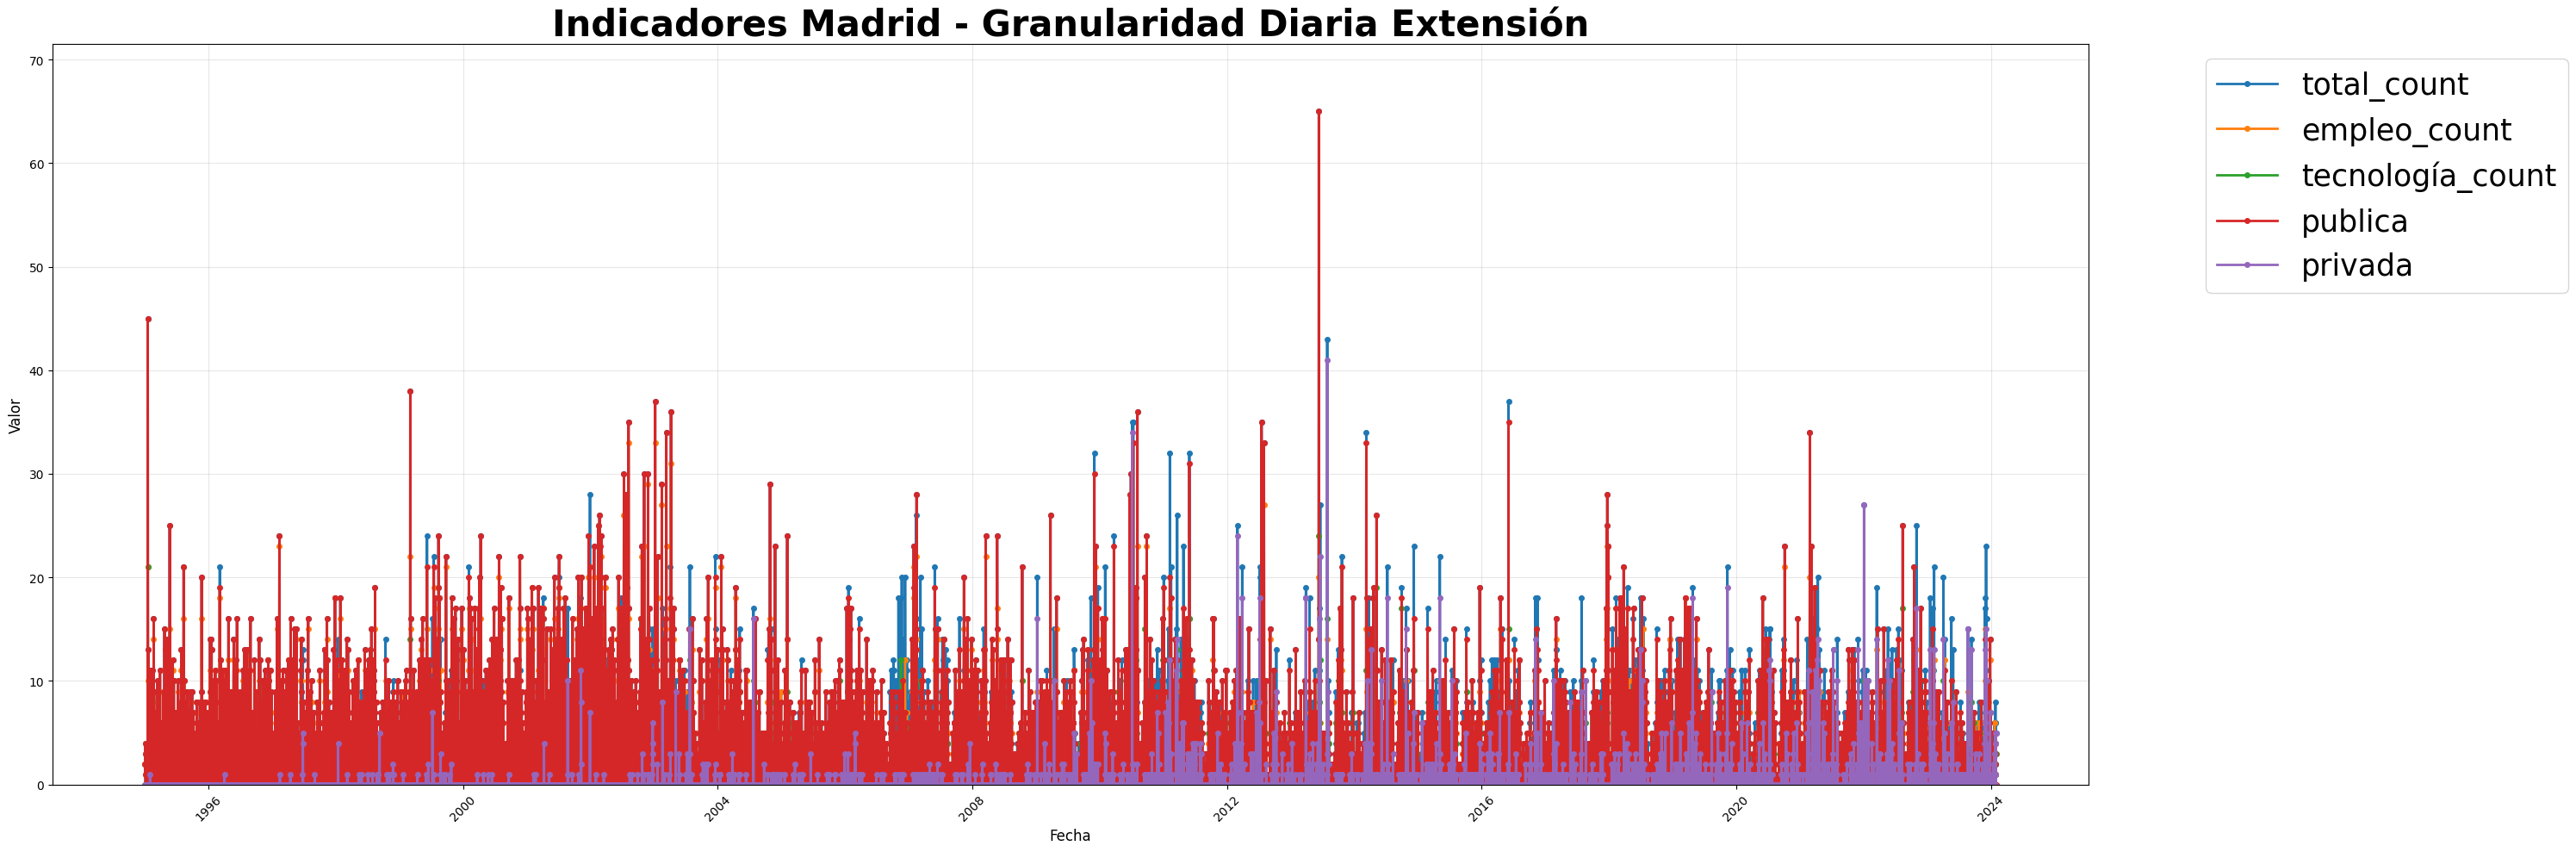

In [25]:
# Y si lo visualizamos en nuestro dataset de madrid particular 
cols_mad_ext = ['total_count', 'empleo_count', 'tecnología_count', 'publica', 'privada']
plot_time_series(dayly_madrid[cols_mad_ext], title="Indicadores Madrid - Granularidad Diaria Extensión", figsize=(30, 10))

Vemos que la magnitud de apariciones de la universidad privada (color morado) es bastante mínima comparada con las apariciones de la universidad pública (color rojo), lo que confirma que tiene sentido también hablar sólo de universidades públicas en la hipótesis inicial. Se descarta de nuevo tal y como se hizo en las primeras gráficas la columna de "privada".

Por otro lado, parece que estas visualizaciones ya sí nos pueden llevar a información útil. Vamos entonces a visualizar cada una de nuestras agregaciones temporales (de la versión general de agrupación, no por comunidades) para tener una primera aproximación de cuál nos puede resultar más útil. 

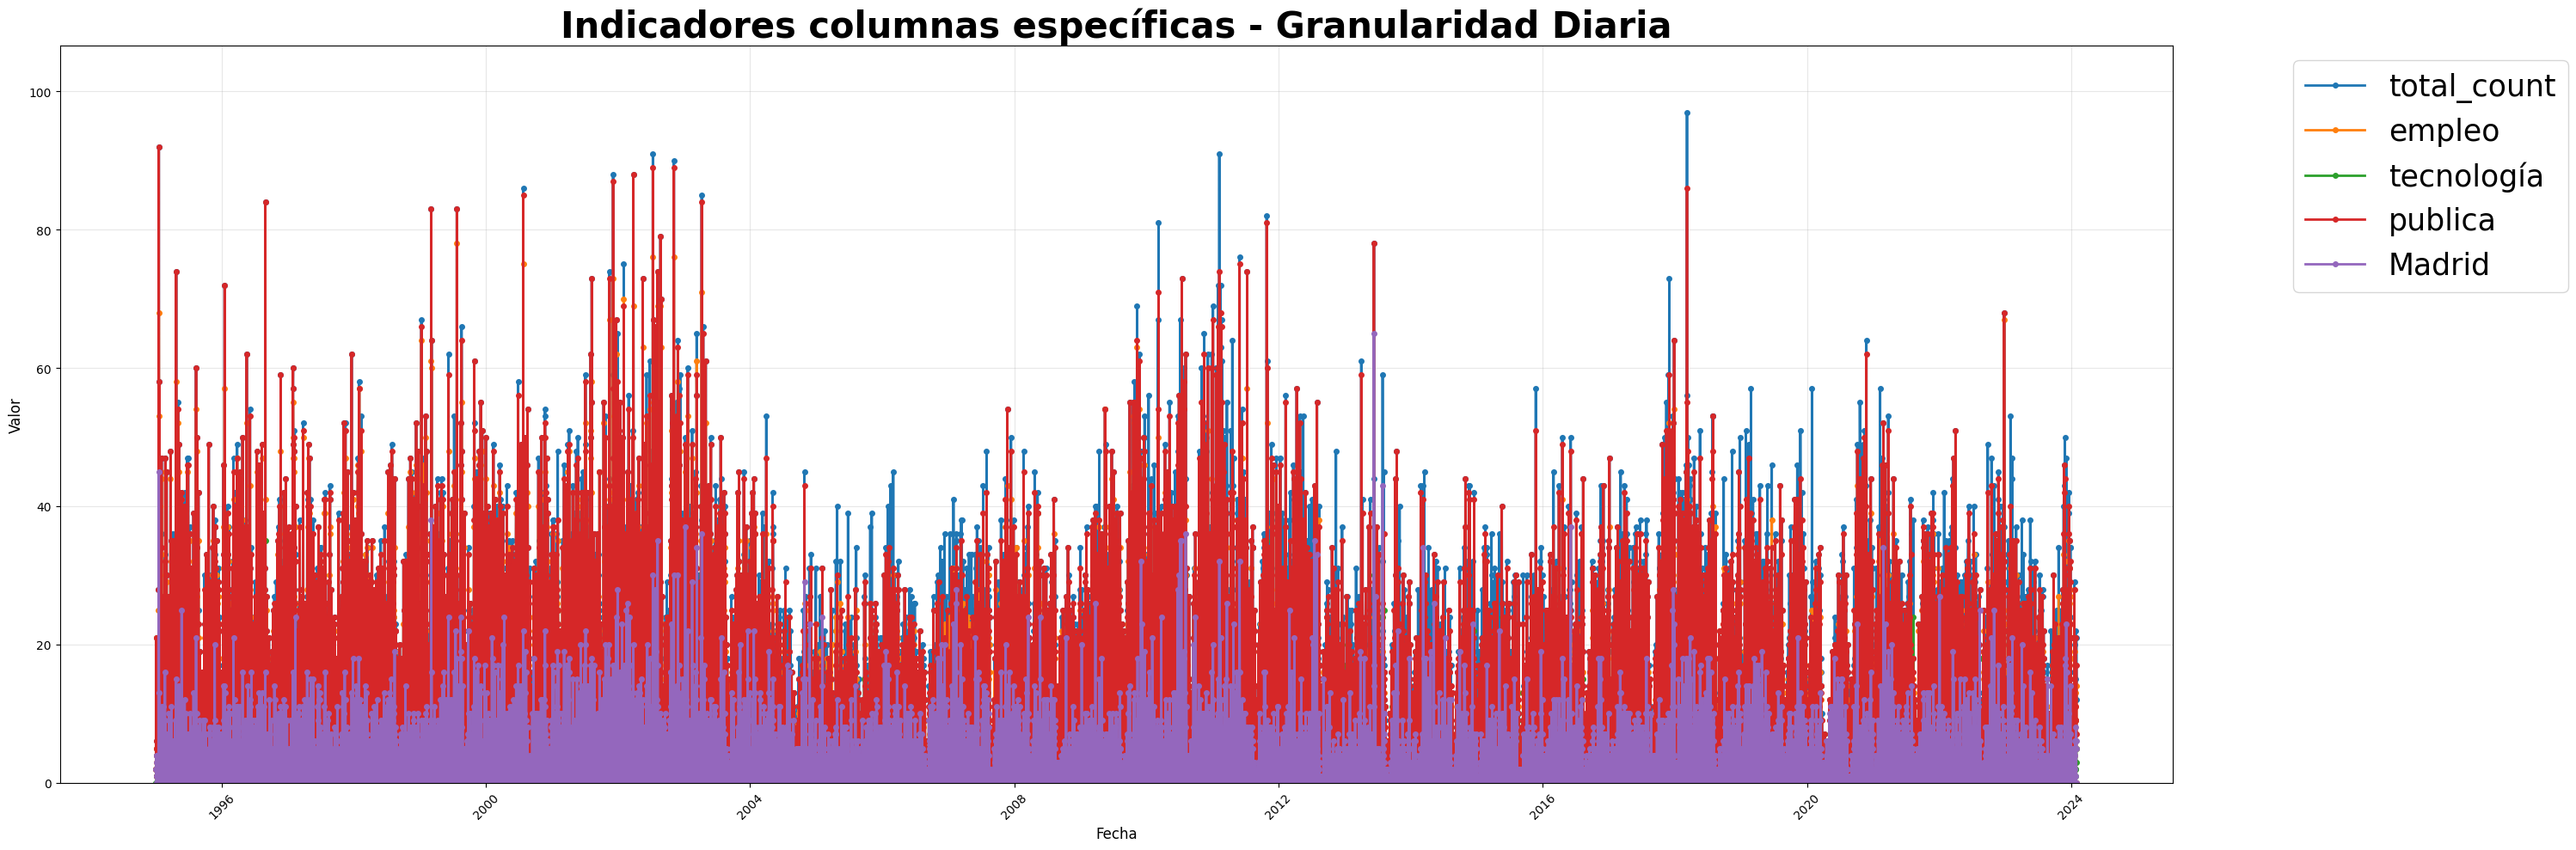

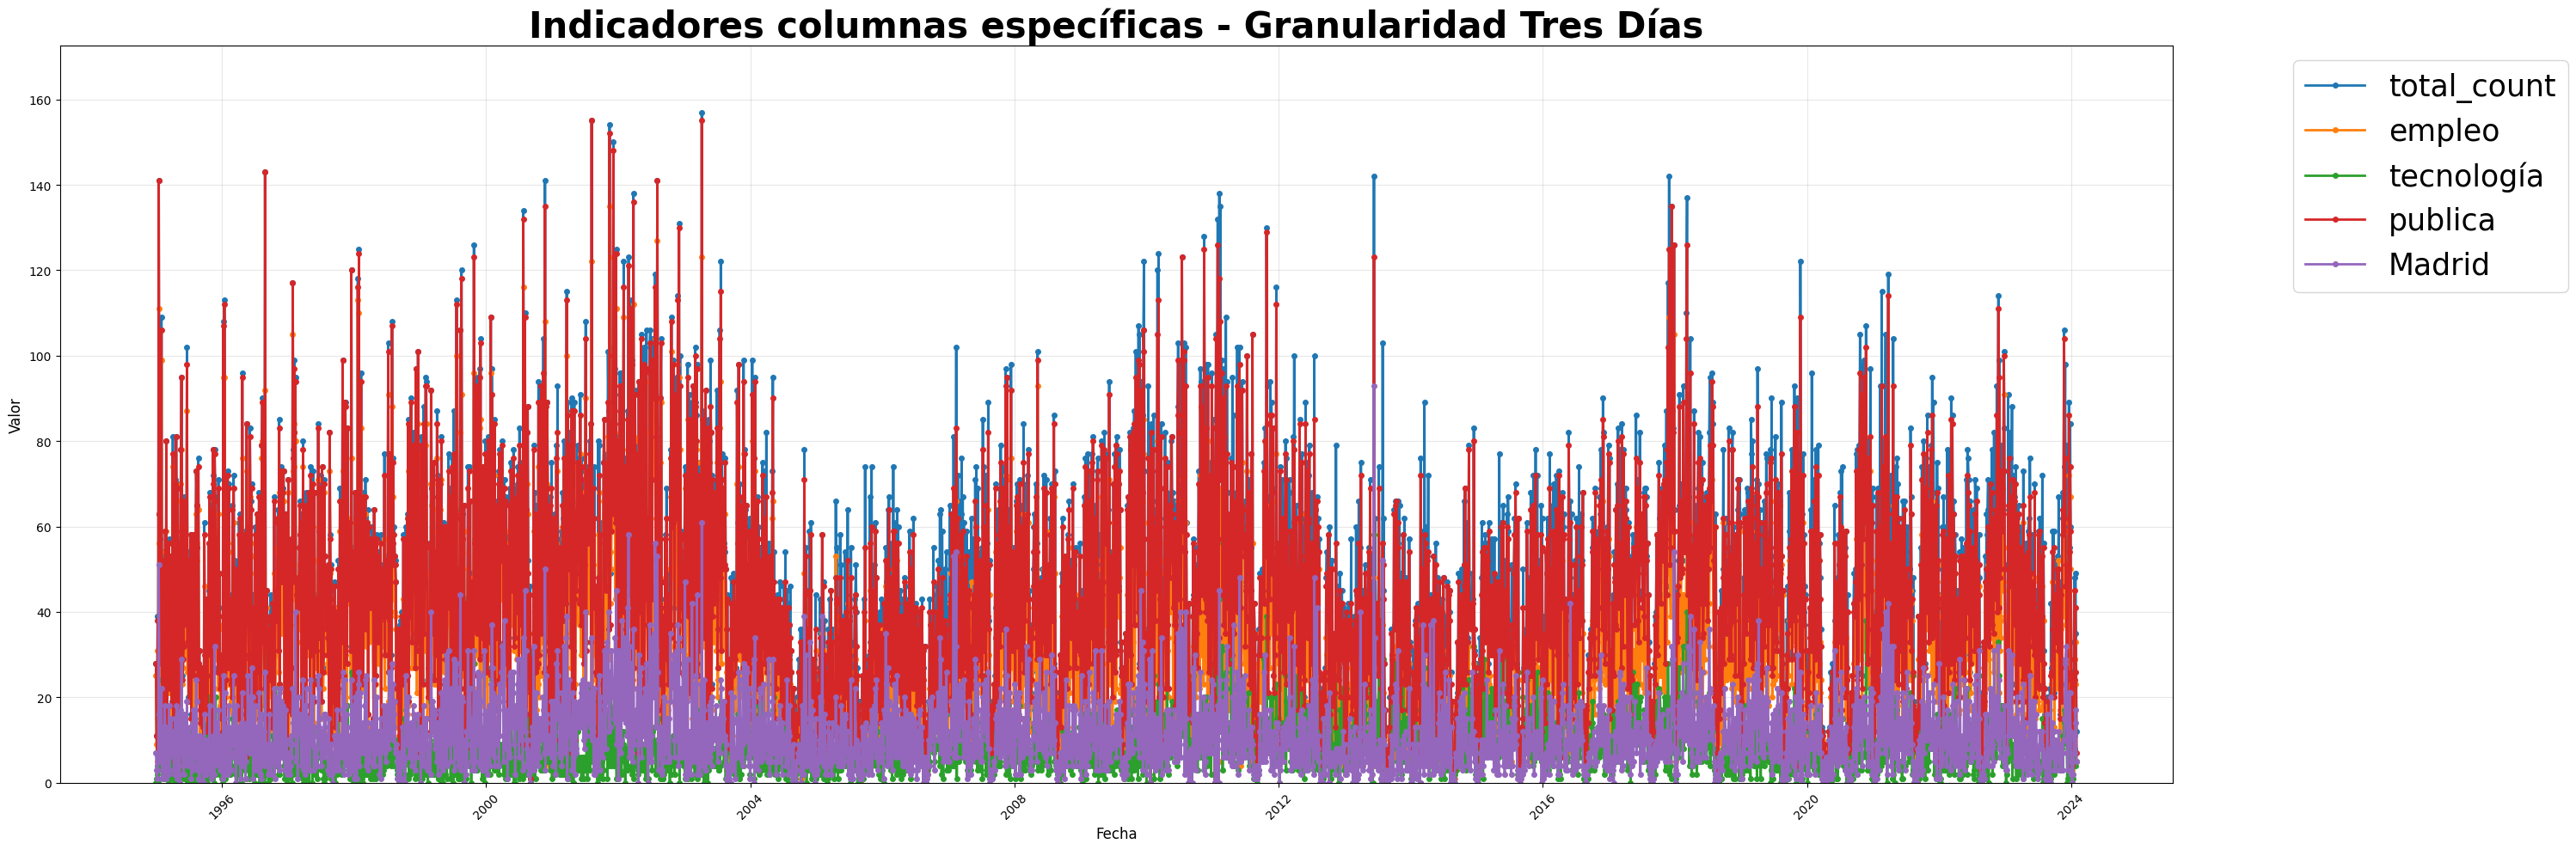

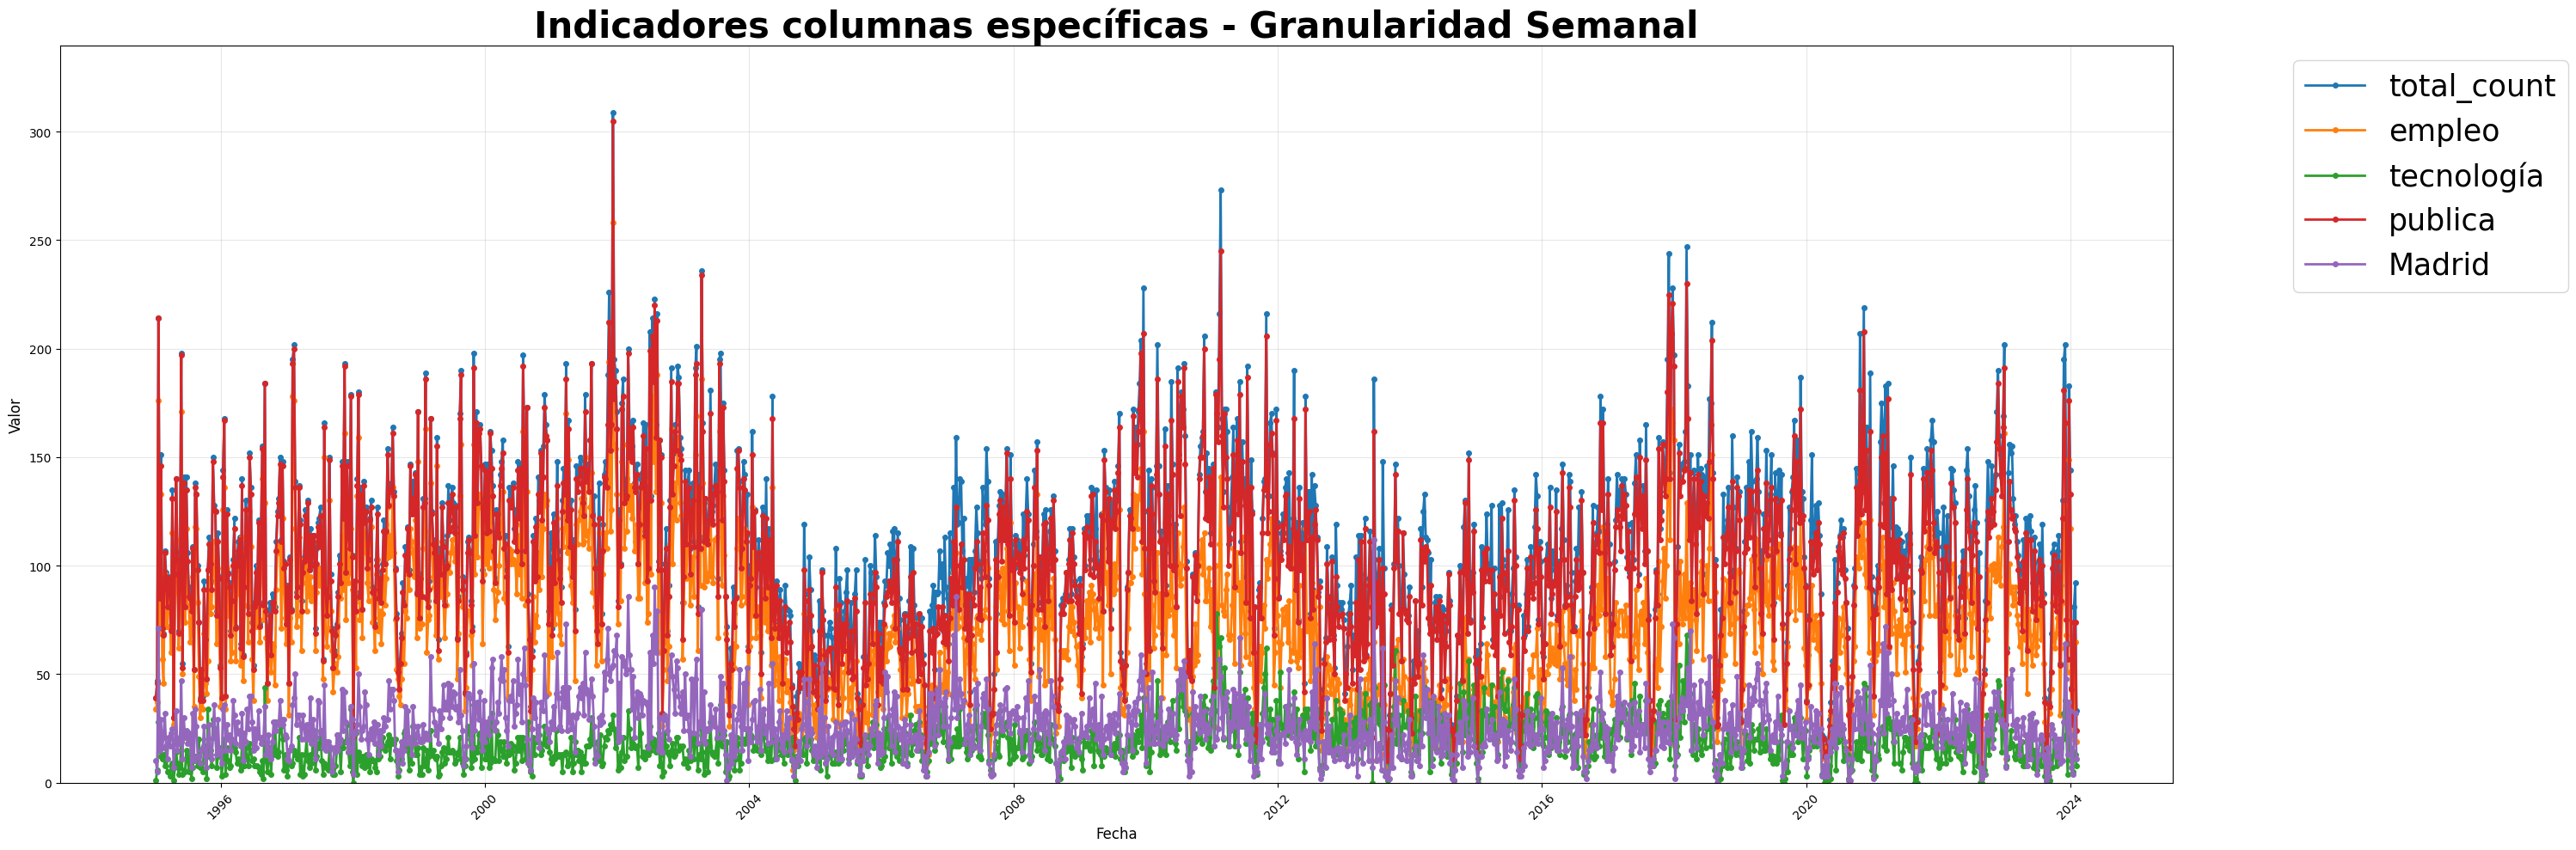

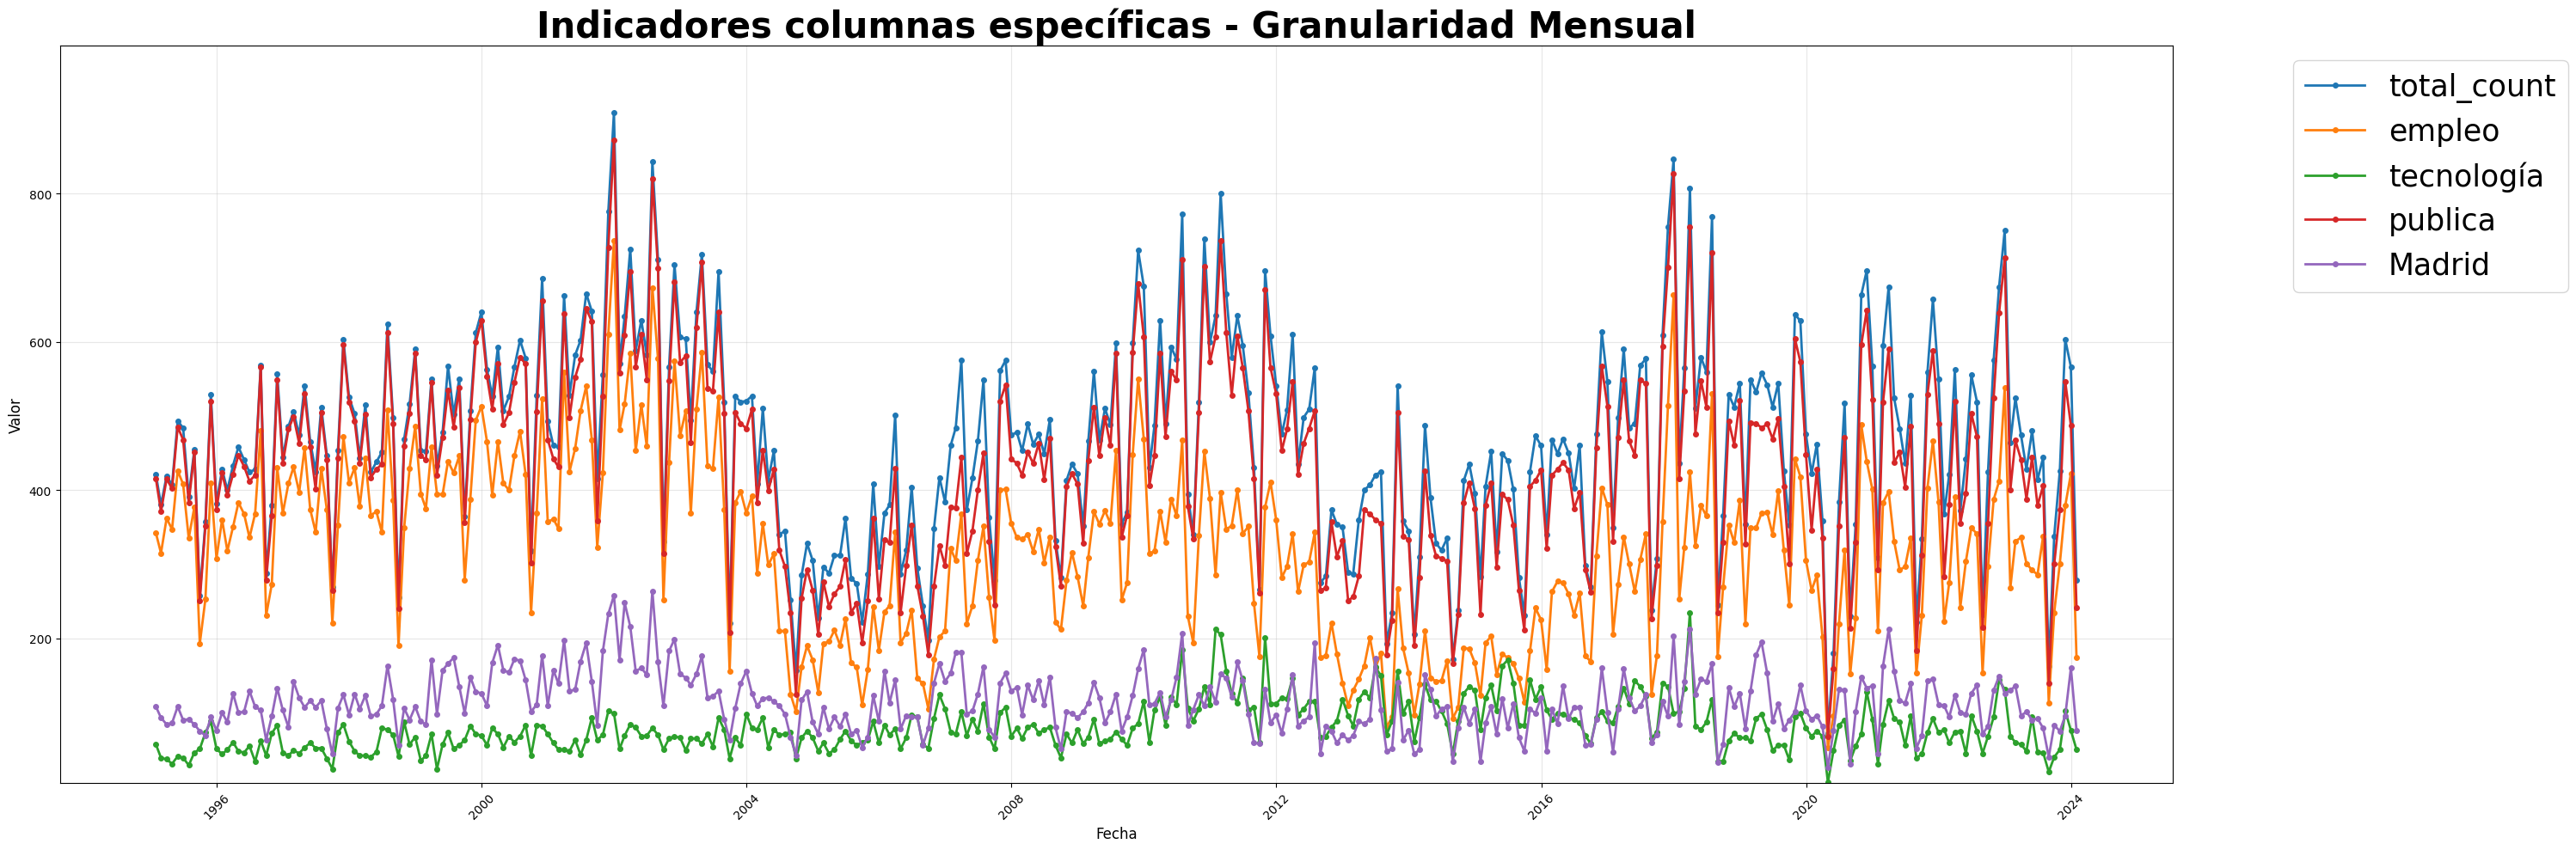

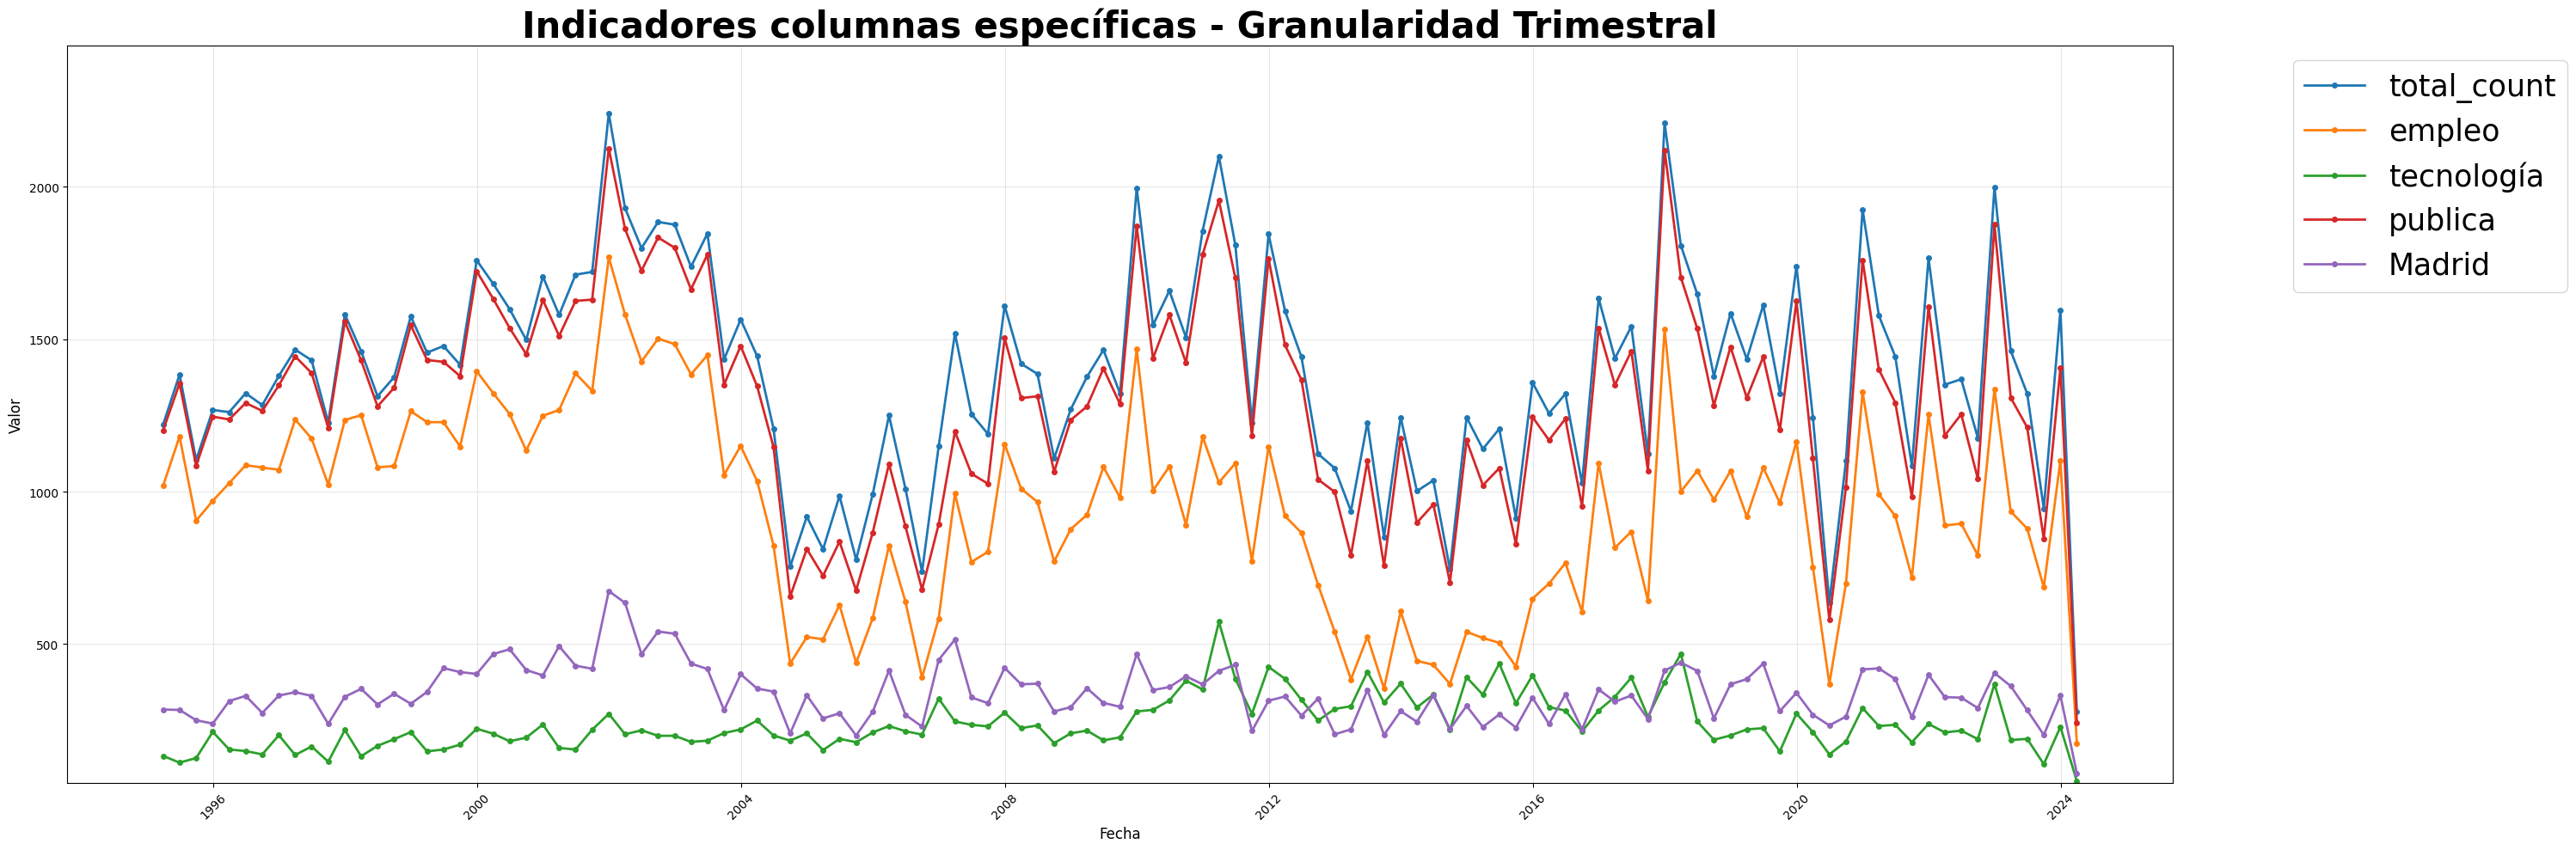

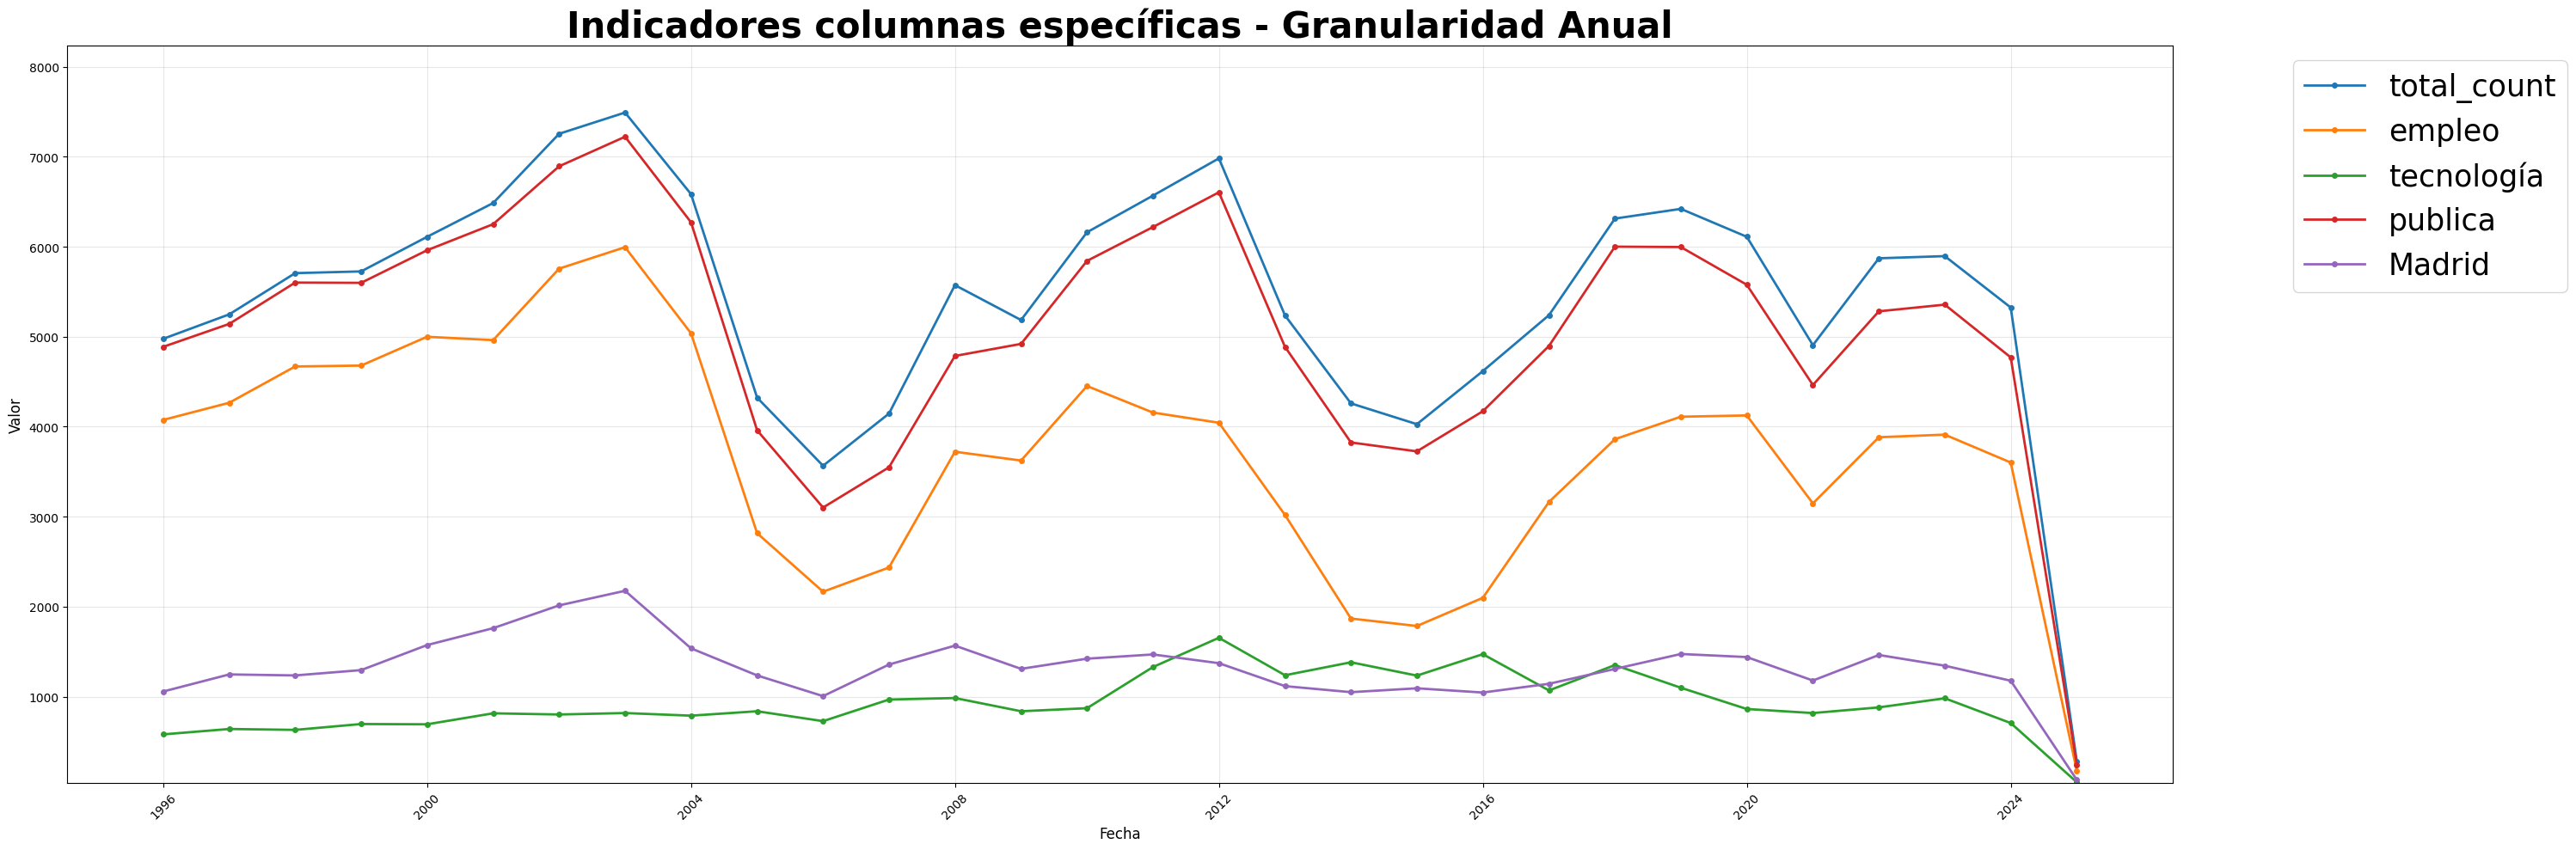

In [26]:
plot_time_series(dayly[cols], title="Indicadores columnas específicas - Granularidad Diaria", figsize=(30, 10)) # reutilizando lista cols
plot_time_series(three_days[cols], title="Indicadores columnas específicas - Granularidad Tres Días", figsize=(30, 10))
plot_time_series(weekly[cols], title="Indicadores columnas específicas - Granularidad Semanal", figsize=(30, 10))
plot_time_series(monthly[cols], title="Indicadores columnas específicas - Granularidad Mensual", figsize=(30, 10))
plot_time_series(quarterly[cols], title="Indicadores columnas específicas - Granularidad Trimestral", figsize=(30, 10))
plot_time_series(annual[cols], title="Indicadores columnas específicas - Granularidad Anual", figsize=(30, 10))

Lo que parece de nuevo confirmar que, aunque ya se había dicho en números, en las visualizaciones se observa de manera más clara que a partir de una granularidad semanal tenemos datos insuficientes para el análisis de nuestra serie temporal y por tanto se descartan dichas granularidades posteriores; recordando que mantenemos la granularidad anual para una visión como conjunto. 

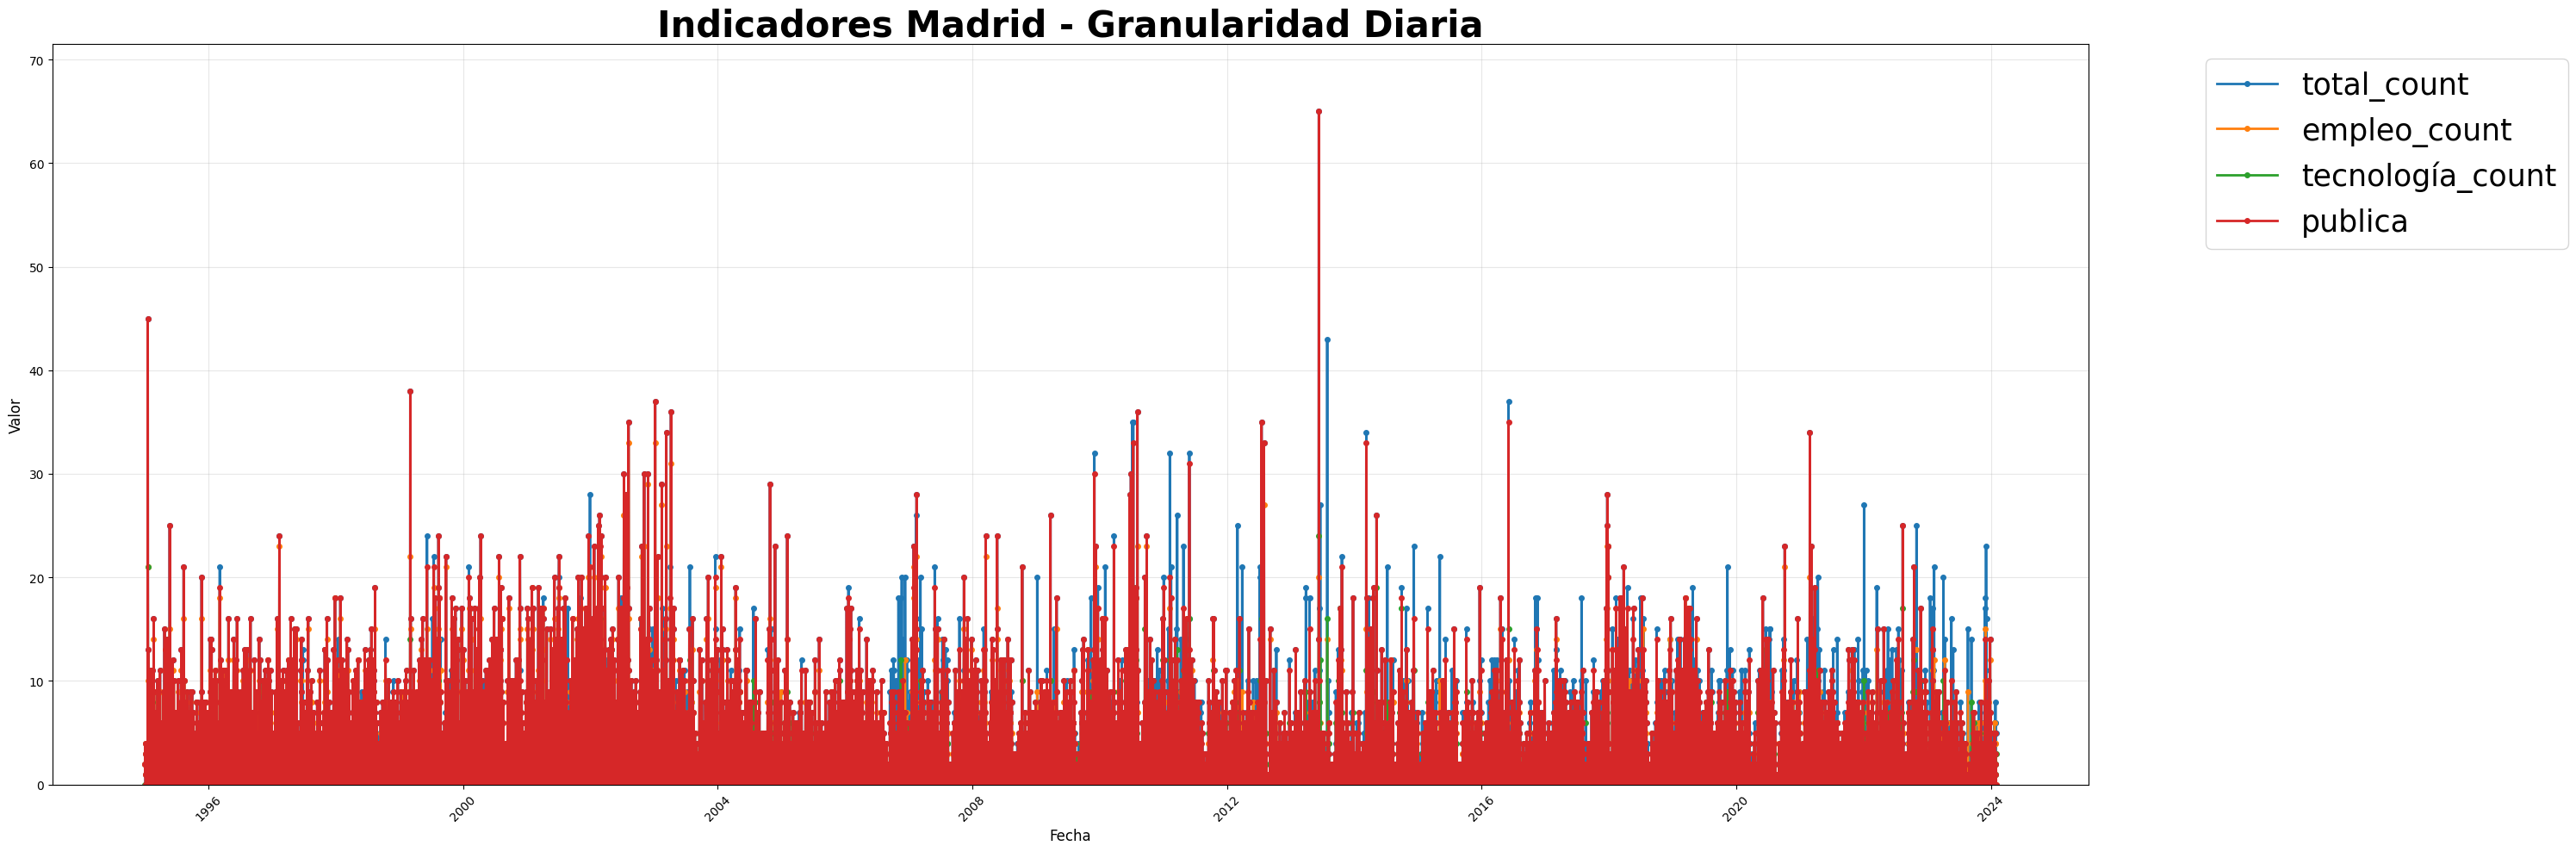

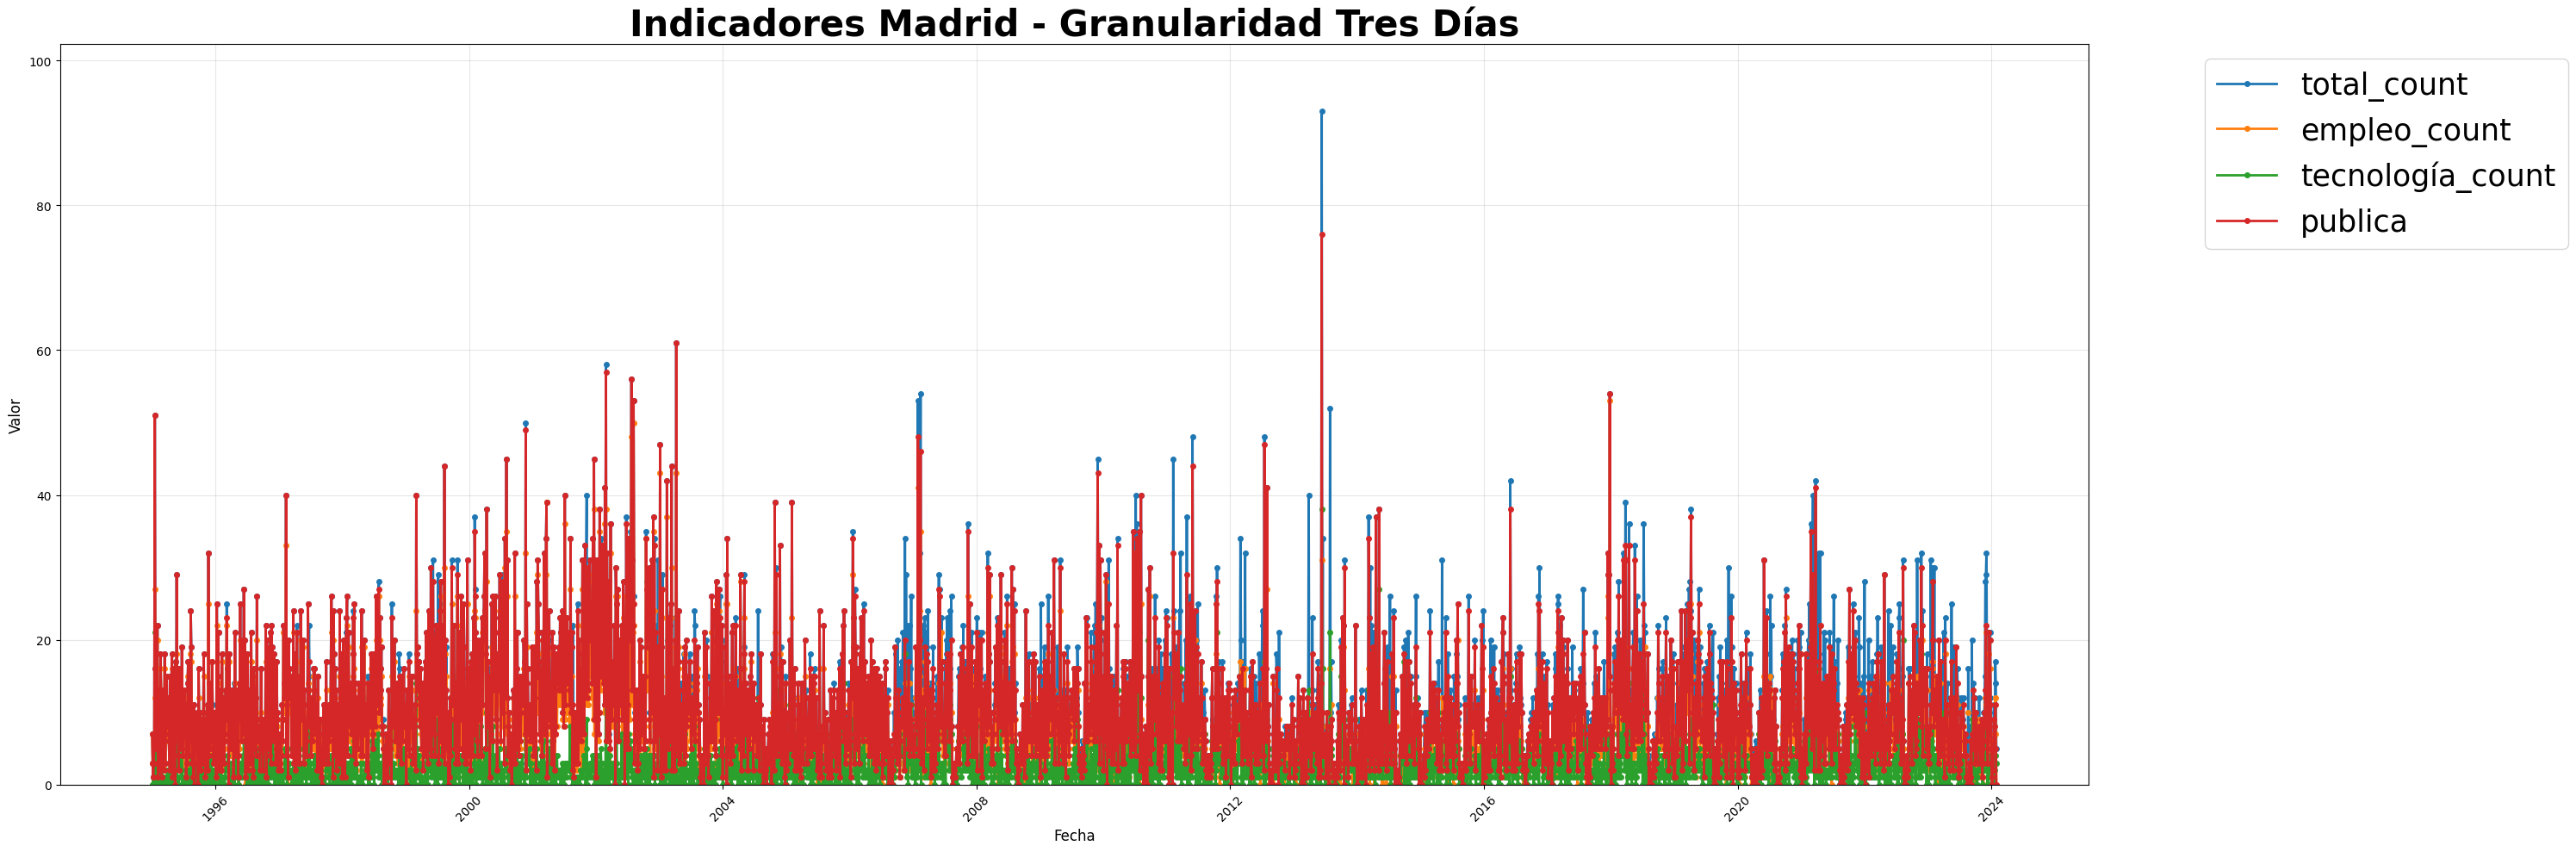

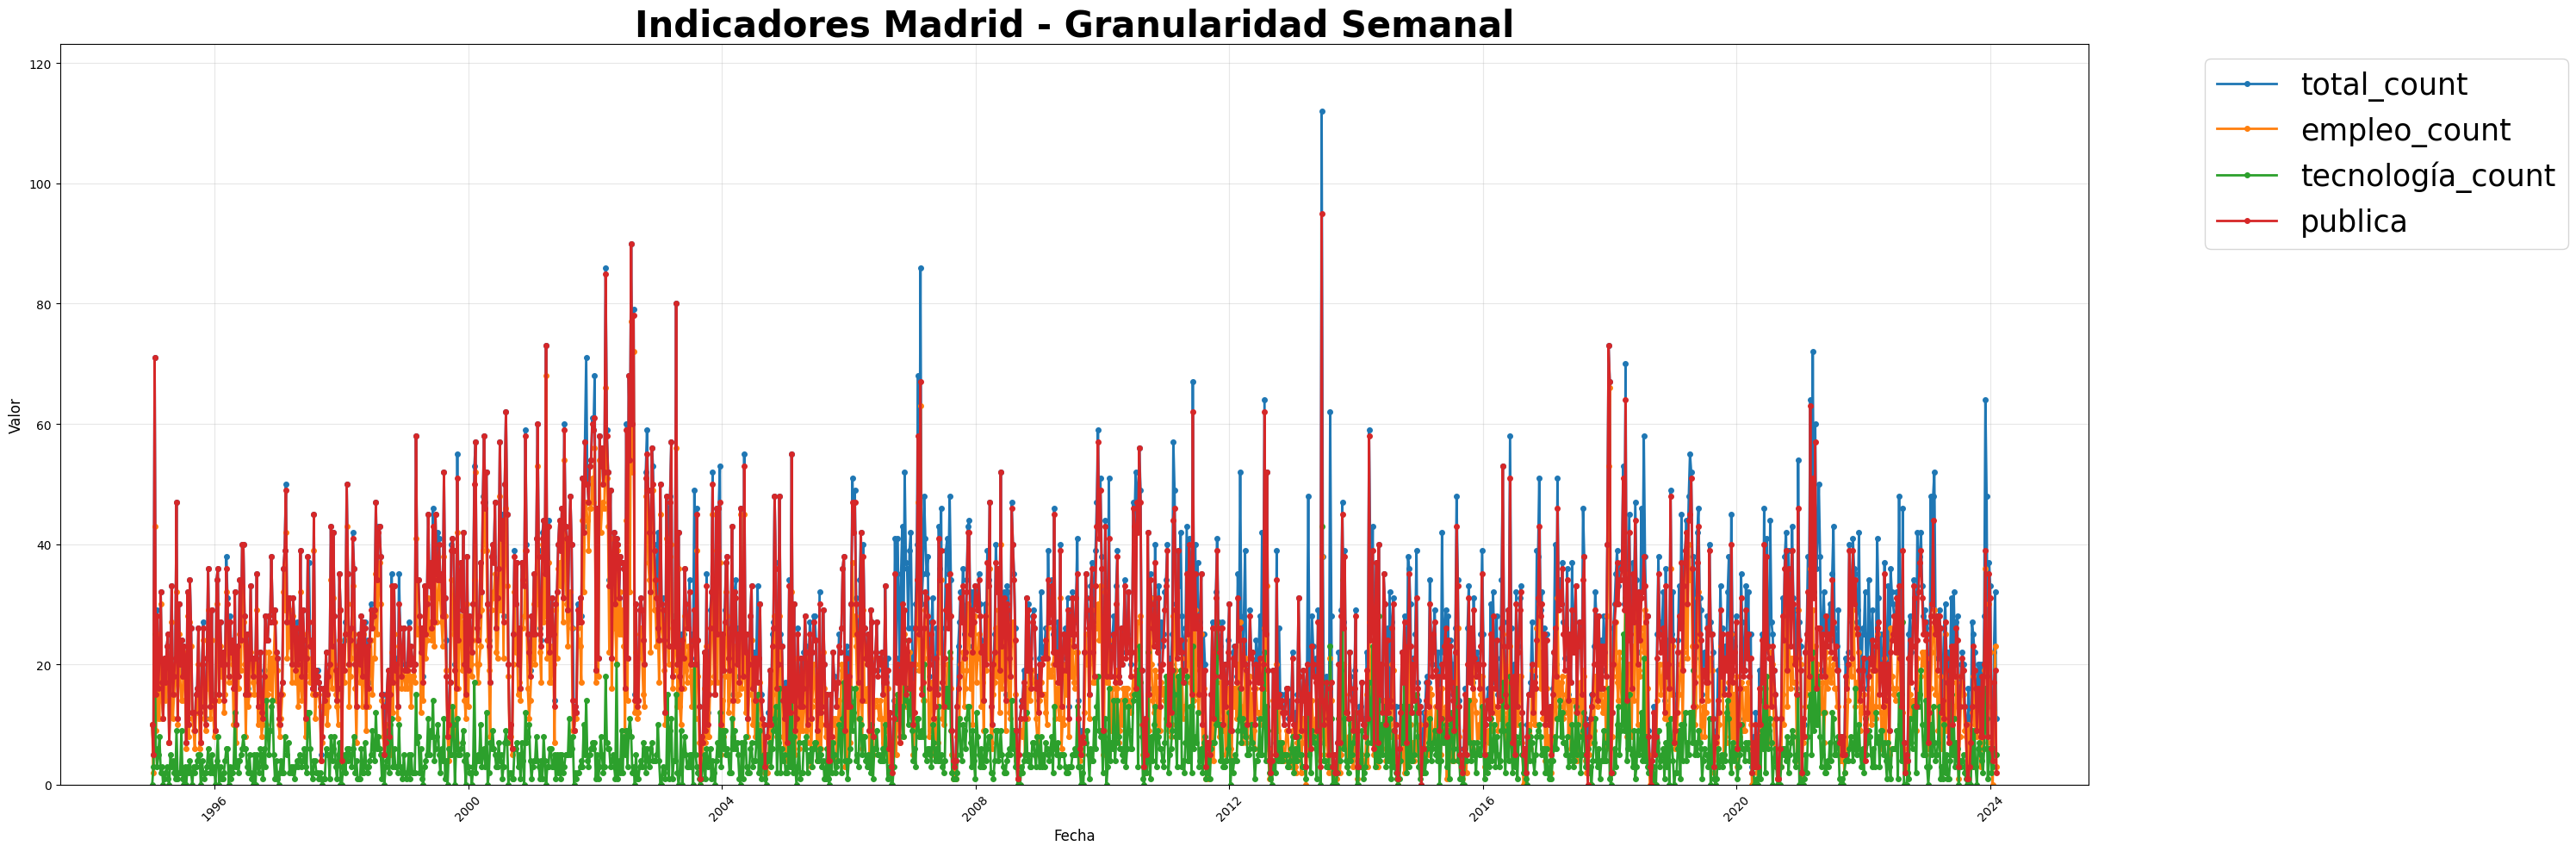

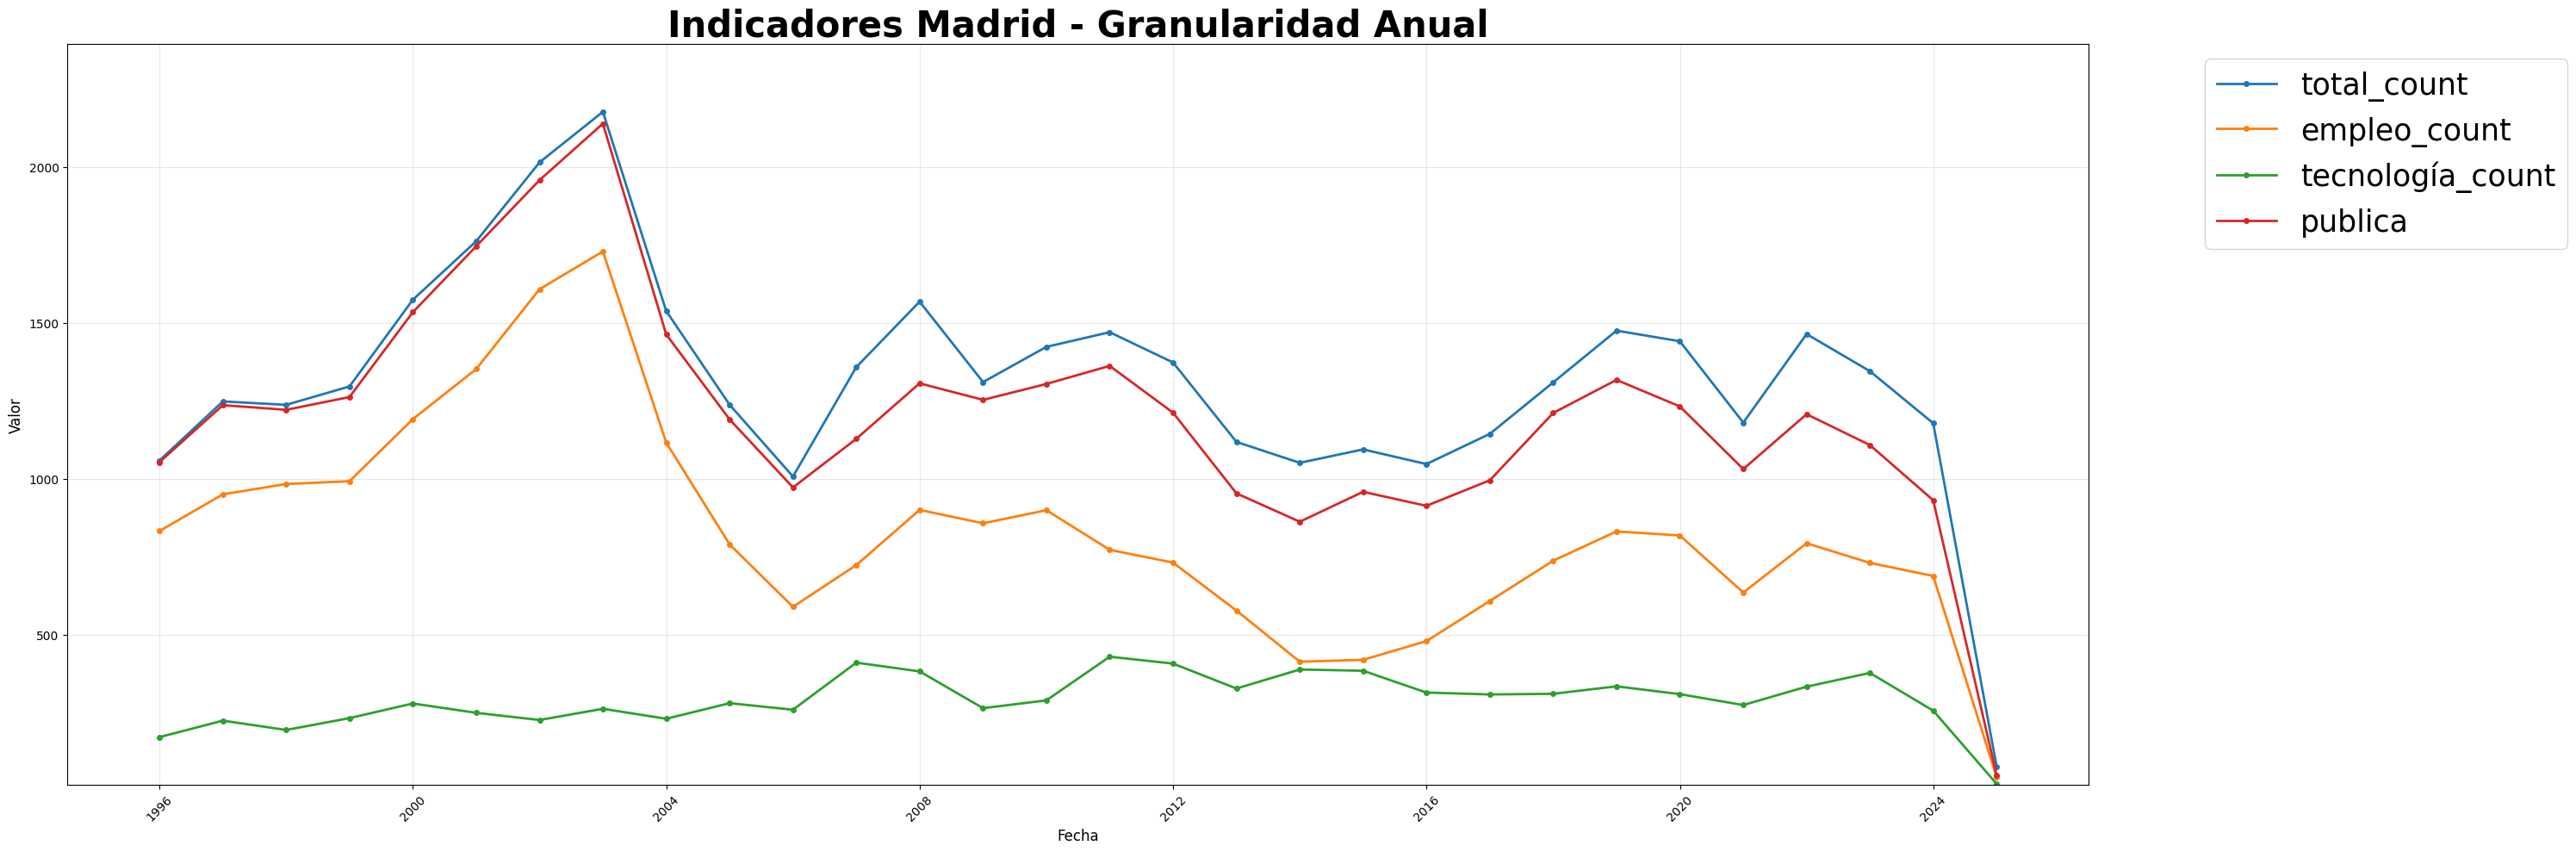

In [27]:
# Y en específico para madrid
plot_time_series(dayly_madrid[cols_mad], title="Indicadores Madrid - Granularidad Diaria", figsize=(30, 10))
plot_time_series(three_days_madrid[cols_mad], title="Indicadores Madrid - Granularidad Tres Días", figsize=(30, 10))
plot_time_series(weekly_madrid[cols_mad], title="Indicadores Madrid - Granularidad Semanal", figsize=(30, 10))
plot_time_series(annual_madrid[cols_mad], title="Indicadores Madrid - Granularidad Anual", figsize=(30, 10))

Parece entonces que las columnas que se mencionan en la hipótesis nos aportan información suficiente y útil y por tanto son susceptibles a un análisis temporal más extenso (con modelos que se aplicarán posteriormente). 

Guardamos nuestros datos "finales" (sin la columna de "privada" dado que hemos visto que su efecto es mínimo para nuestra hipótesis) para poder utilizarlos en procesos posteriores. Guardamos sólo nuestros datos con agrupación diaria ya que es el subconjunto más grande y que nos dará mayores posibilidades de análisis. 

In [28]:
dayly_madrid.drop(columns=["privada"]).to_csv("indicators_madrid_dayly.csv")
annual_madrid.drop(columns=["privada"]).to_csv("indicators_madrid_annual.csv")  # Se usará en uno de los análisis posteriores

# Descomentar estas lineas si se quieren guardar los otros dos conjuntos de la misma manera
# three_days_madrid.drop(columns=["privada"]).to_csv("indicators_madrid_three_days.csv")
# weekly_madrid.drop(columns=["privada"]).to_csv("indicators_madrid_weekly.csv")